# Ablation 5 — Depth Recurrence

Sweeps `recur_layers` (1 seed, 5 000 steps, warmdown 750), with `recur_times=1` (each selected block runs **twice** total, with **shared weights**).

| config | meaning |
|---|---|
| `[4]`     | repeat only the first decoder block |
| `[4, 5]`  | repeat the first two decoder blocks (mirrors leaderboard entry) |
| `[3, 4]`  | repeat last encoder + first decoder (straddle the U-Net hinge) |
| `[5, 6]`  | repeat deeper decoder blocks |


**Depth recurrence** runs selected transformer blocks more than once with the *same* weights — no extra parameters, just extra FLOPs. The block sees its own output on the second pass (skip connections are not re-injected). Conceptually it's an unrolled fixed-point iteration: each repeated block refines its own representation before passing it downstream. The hyperparameter is `recur_layers`, the indices of the blocks that get the extra pass; in the U-Net architecture used here, layers 0–3 are encoder, 4–8 are decoder.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

N_LAYERS = 9

# Ablation 5 — display order, labels, colors
RECUR_ORDER  = ["[4]", "[4, 5]", "[3, 4]", "[5, 6]"]
RECUR_LABELS = {
    "[4]":     "Recur L4 (1 layer)",
    "[4, 5]":  "Recur L4-L5 (2 layers, decoder)",
    "[3, 4]":  "Recur L3-L4 (2 layers, hinge)",
    "[5, 6]":  "Recur L5-L6 (2 layers, deep)",
}
RECUR_COLORS = {k: PALETTE[i] for i, k in enumerate(RECUR_ORDER)}


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/antonio2/.netrc.


## Original Baseline (3 seeds, reference)


In [2]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN = df_base["final_val_bpb"].mean()
BASE_BPB_STD  = df_base["final_val_bpb"].std()

print("=" * 50)
print("ORIGINAL BASELINE  (3 seeds, warmdown 750)")
print("=" * 50)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print("=" * 50)


ORIGINAL BASELINE  (3 seeds, warmdown 750)
 seed  final_val_bpb  final_val_loss
   42       1.311465        2.214354
  123       1.309002        2.210195
 1337       1.309833        2.211598

final_val_bpb : 1.3101 ± 0.0013


## Ablation 5 — Depth Recurrence


In [3]:
ABL5_PREFIX = "ablation5_depth_recurrence"

abl5_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL5_PREFIX}"}},
))

rows = []
for run in abl5_runs:
    s   = run.summary._json_dict
    cfg = run.config
    layers = sorted(cfg.get("recur_layers", []))
    rows.append({
        "run_name":         run.name,
        "recur_layers":     str(layers),
        "label":            RECUR_LABELS.get(str(layers), str(layers)),
        "recur_times":      cfg.get("recur_times", 1),
        "seed":             cfg.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df = (
    pd.DataFrame(rows)
    .assign(order=lambda d: d["recur_layers"].map({v: i for i, v in enumerate(RECUR_ORDER)}))
    .sort_values("order")
    .reset_index(drop=True)
    .drop(columns="order")
)
df


,run_name,recur_layers,label,recur_times,seed,final_val_bpb,final_val_loss,quant_file_bytes
0,ablation5_depth_recurrence_layers4_seed1337,[4],Recur L4 (1 layer),1,1337,1.307638,2.207893,15761282
1,ablation5_depth_recurrence_layers4_5_seed1337,"[4, 5]","Recur L4-L5 (2 layers, decoder)",1,1337,1.306604,2.206146,15766806
2,ablation5_depth_recurrence_layers3_4_seed1337,"[3, 4]","Recur L3-L4 (2 layers, hinge)",1,1337,1.304761,2.203034,15758151
3,ablation5_depth_recurrence_layers5_6_seed1337,"[5, 6]","Recur L5-L6 (2 layers, deep)",1,1337,1.310317,2.212416,15754661


In [4]:
best = df.loc[df["final_val_bpb"].idxmin()]

print(f"Original baseline (3-seed mean) : {BASE_BPB_MEAN:.4f} bpb")
print(f"Best recurrence config          : {best['label']}  ({best['recur_layers']})")
print(f"  final_val_bpb                 : {best['final_val_bpb']:.4f}")
delta = BASE_BPB_MEAN - best['final_val_bpb']
print(f"  Δ vs baseline                 : {delta:+.4f} bpb  ({'better' if delta > 0 else 'worse'})")


Original baseline (3-seed mean) : 1.3101 bpb
Best recurrence config          : Recur L3-L4 (2 layers, hinge)  ([3, 4])
  final_val_bpb                 : 1.3048
  Δ vs baseline                 : +0.0053 bpb  (better)


### Final val_bpb — bar chart with baseline reference


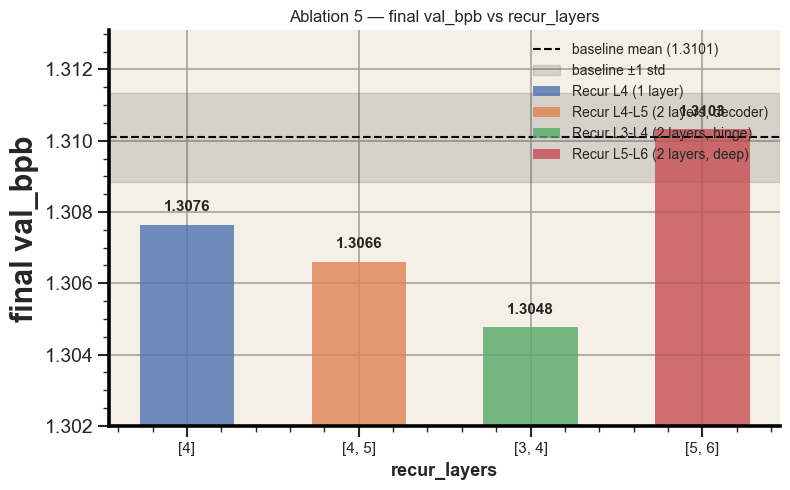

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

x_pos  = list(range(len(RECUR_ORDER)))
y_vals = [df.loc[df["recur_layers"] == k, "final_val_bpb"].values[0] for k in RECUR_ORDER]

for i, (k, y) in enumerate(zip(RECUR_ORDER, y_vals)):
    ax.bar(i, y, color=RECUR_COLORS[k], alpha=0.80, width=0.55, zorder=2,
           label=RECUR_LABELS[k])
    ax.text(i, y + 0.0003, f"{y:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.12, color="black", label="baseline ±1 std")

ax.set_xticks(x_pos)
ax.set_xticklabels(RECUR_ORDER, fontsize=11)
ax.set_xlabel("recur_layers", fontsize=13, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 5 — final val_bpb vs recur_layers")

# tight y-range
all_bpb = y_vals + [BASE_BPB_MEAN]
pad = (max(all_bpb) - min(all_bpb)) * 0.5
ax.set_ylim(min(all_bpb) - pad, max(all_bpb) + pad)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()


### Quantised model size — does recurrence change it?

Depth recurrence shares weights, so we expect the model file size to be **identical** across configs (and identical to the sequential baseline). This plot is a sanity check: if a bar deviates, something stored extra state.


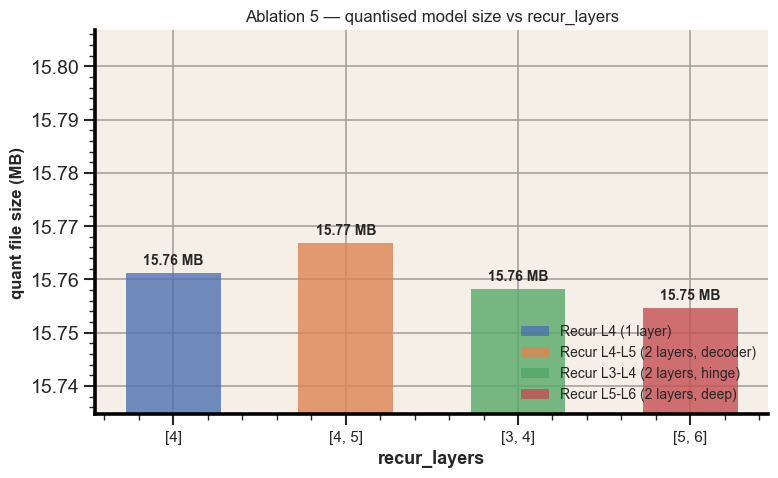

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

size_mb = [df.loc[df["recur_layers"] == k, "quant_file_bytes"].values[0] / 1e6 for k in RECUR_ORDER]

for i, (k, mb) in enumerate(zip(RECUR_ORDER, size_mb)):
    ax.bar(i, mb, color=RECUR_COLORS[k], alpha=0.80, width=0.55, zorder=2,
           label=RECUR_LABELS[k])
    ax.text(i, mb + 0.001, f"{mb:.2f} MB", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_xticks(range(len(RECUR_ORDER)))
ax.set_xticklabels(RECUR_ORDER, fontsize=11)
ax.set_xlabel("recur_layers", fontsize=13, fontweight="bold")
ax.set_ylabel("quant file size (MB)", fontsize=12)
ax.set_title("Ablation 5 — quantised model size vs recur_layers")
ymin = min(size_mb) - 0.02
ymax = max(size_mb) + 0.04
ax.set_ylim(ymin, ymax)
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout(pad=1.5)
plt.show()


### Learning curves — val_bpb and train_loss


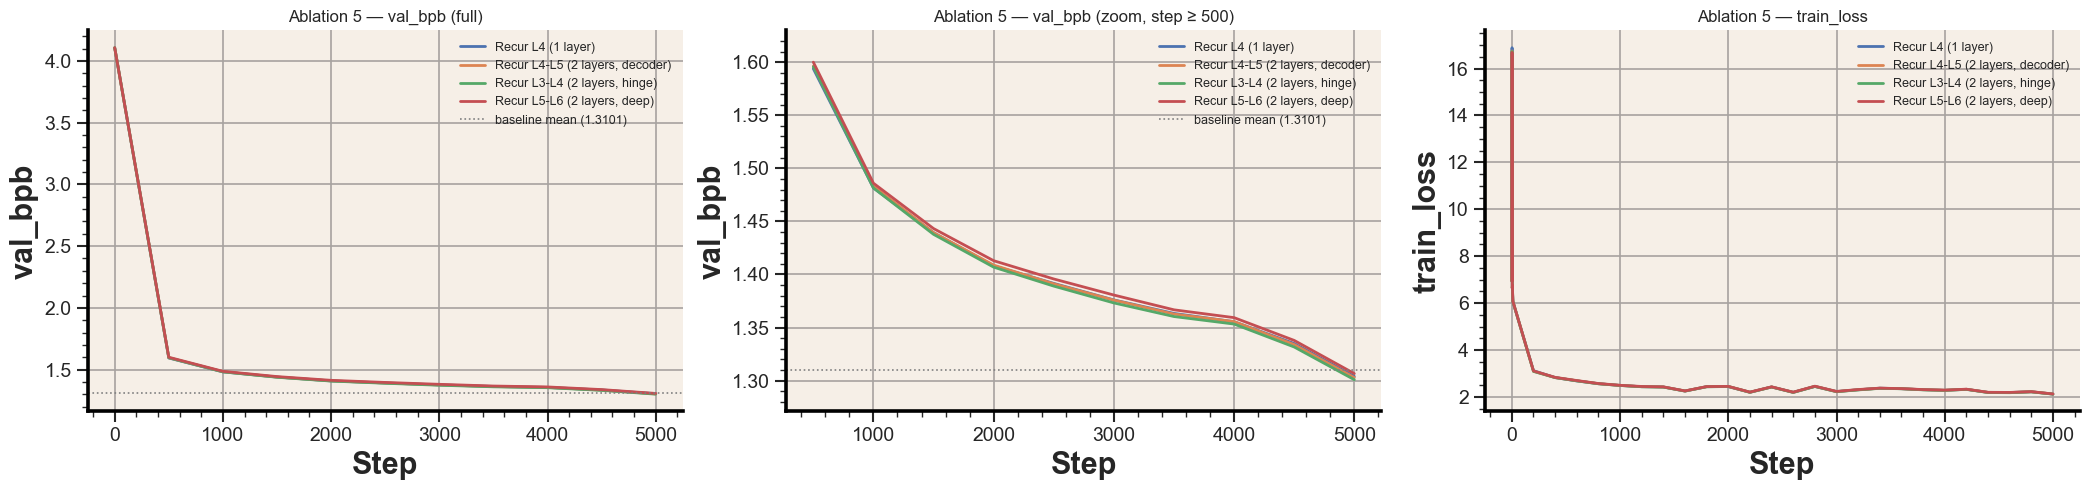

In [7]:
def fetch_history(runs, metric, key="recur_layers"):
    """Returns {recur_layers_str: DataFrame} sorted by RECUR_ORDER."""
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            k = str(sorted(run.config.get(key, [])))
            histories[k] = hist
    return {k: histories[k] for k in RECUR_ORDER if k in histories}

histories_bpb   = fetch_history(abl5_runs, "val_bpb")
histories_train = fetch_history(abl5_runs, "train_loss")

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# --- full val_bpb ---
ax = axes[0]
for k, hist in histories_bpb.items():
    ax.plot(hist["step"], hist["val_bpb"],
            label=RECUR_LABELS[k], color=RECUR_COLORS[k], linewidth=2)
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title("Ablation 5 — val_bpb (full)")
ax.legend(fontsize=9)

# --- zoomed val_bpb (plateau region) ---
ax = axes[1]
ZOOM_STEP = 500
for k, hist in histories_bpb.items():
    h = hist[hist["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label=RECUR_LABELS[k], color=RECUR_COLORS[k], linewidth=2)
all_vals = [h.loc[h["step"] >= ZOOM_STEP, "val_bpb"] for h in histories_bpb.values()]
ymin = min(v.min() for v in all_vals)
ymax = max(v.max() for v in all_vals)
pad  = (ymax - ymin) * 0.1
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_ylim(min(ymin, BASE_BPB_MEAN) - pad, max(ymax, BASE_BPB_MEAN) + pad)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title(f"Ablation 5 — val_bpb (zoom, step ≥ {ZOOM_STEP})")
ax.legend(fontsize=9)

# --- full train_loss ---
ax = axes[2]
for k, hist in histories_train.items():
    ax.plot(hist["step"], hist["train_loss"],
            label=RECUR_LABELS[k], color=RECUR_COLORS[k], linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("train_loss")
ax.set_title("Ablation 5 — train_loss")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Generalisation gap — val_loss − train_loss

If recurrence is buying *capacity* (memorising train tokens) the gap widens; if it's improving *representations* the gap stays flat or shrinks.


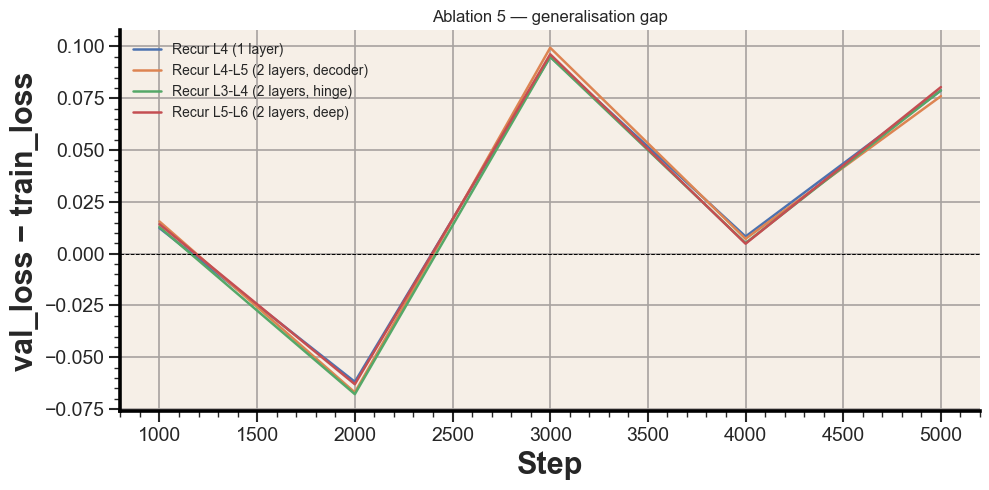

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

histories_val_loss = fetch_history(abl5_runs, "val_loss")

for k in RECUR_ORDER:
    if k not in histories_train or k not in histories_val_loss:
        continue
    tr  = histories_train[k].rename(columns={"train_loss": "tr"})
    vl  = histories_val_loss[k].rename(columns={"val_loss": "vl"})
    h   = pd.merge(tr, vl, on="step", how="inner")
    ax.plot(h["step"], h["vl"] - h["tr"],
            label=RECUR_LABELS[k], color=RECUR_COLORS[k], linewidth=1.8)

ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_xlabel("Step")
ax.set_ylabel("val_loss − train_loss")
ax.set_title("Ablation 5 — generalisation gap")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Summary table — all configs vs baseline


In [9]:
summary = df[["label", "recur_layers", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].copy()
summary["Δ vs baseline"] = (BASE_BPB_MEAN - summary["final_val_bpb"]).map(lambda x: f"{x:+.4f}")
summary = summary.rename(columns={
    "label":            "config",
    "final_val_bpb":    "val_bpb",
    "final_val_loss":   "val_loss",
    "quant_file_bytes": "model_bytes",
})

print(summary.to_string(index=False))
print(f"\nOriginal baseline (3-seed mean): {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")

best_label = df.loc[df["final_val_bpb"].idxmin(), "label"]
best_bpb   = df["final_val_bpb"].min()
verdict    = "BETTER" if best_bpb < BASE_BPB_MEAN else "WORSE"
print(f"\nConclusion: best config ({best_label}) is {verdict} than baseline by "
      f"{abs(BASE_BPB_MEAN - best_bpb):.4f} bpb.")


                         config recur_layers  val_bpb  val_loss  model_bytes Δ vs baseline
             Recur L4 (1 layer)          [4] 1.307638  2.207893     15761282       +0.0025
Recur L4-L5 (2 layers, decoder)       [4, 5] 1.306604  2.206146     15766806       +0.0035
  Recur L3-L4 (2 layers, hinge)       [3, 4] 1.304761  2.203034     15758151       +0.0053
   Recur L5-L6 (2 layers, deep)       [5, 6] 1.310317  2.212416     15754661       -0.0002

Original baseline (3-seed mean): 1.3101 ± 0.0013 bpb

Conclusion: best config (Recur L3-L4 (2 layers, hinge)) is BETTER than baseline by 0.0053 bpb.


---
## Ablation 5b — Where does depth recurrence happen?

Ablation 5 re-ran the **whole block** (attention + MLP, with `resid_mix` re-applied). Ablation 5b fixes the layer set to `[4, 5]` and sweeps which sub-component runs the extra pass.

| target | meaning |
|---|---|
| `attn`  | only the attention sub-layer runs the extra pass (iterative *routing*) |
| `mlp`   | only the MLP sub-layer runs the extra pass (iterative *feature building*) |
| `both`  | both sub-layers run the extra pass (`resid_mix` is **not** re-applied) |

The natural reference is the ablation-5 `[4, 5]` run (whole block + `resid_mix` re-applied) — same compute footprint as `target=both`, only the gate handling differs.


In [10]:
ABL5B_PREFIX = "ablation5b_recur_target"

abl5b_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL5B_PREFIX}"}},
))

TARGET_ORDER  = ["attn", "mlp", "both"]
TARGET_LABELS = {
    "attn": "target=attn (iter. routing)",
    "mlp":  "target=mlp  (iter. features)",
    "both": "target=both (no resid_mix)",
}
TARGET_COLORS = {t: PALETTE[i] for i, t in enumerate(TARGET_ORDER)}

abl5b_rows = []
for run in abl5b_runs:
    s   = run.summary._json_dict
    cfg = run.config
    target = cfg.get("recur_target")
    abl5b_rows.append({
        "run_name":         run.name,
        "recur_target":     target,
        "label":            TARGET_LABELS.get(target, target),
        "recur_layers":     str(sorted(cfg.get("recur_layers", []))),
        "recur_times":      cfg.get("recur_times", 1),
        "seed":             cfg.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df5b = (
    pd.DataFrame(abl5b_rows)
    .assign(order=lambda d: d["recur_target"].map({v: i for i, v in enumerate(TARGET_ORDER)}))
    .sort_values("order")
    .reset_index(drop=True)
    .drop(columns="order")
)

# ablation 5 reference: whole block on [4, 5]
abl5_ref_bpb = df.loc[df["recur_layers"] == "[4, 5]", "final_val_bpb"].values[0]

print("=" * 65)
print("ABLATION 5b — sub-component recurrence on layers [4, 5]")
print("=" * 65)
print(df5b[["label", "seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].to_string(index=False))
print(f"\nReference — abl5 [4, 5] (whole block) : {abl5_ref_bpb:.4f} bpb")
print(f"Original baseline (3-seed mean)        : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")
print("=" * 65)


ABLATION 5b — sub-component recurrence on layers [4, 5]
                       label  seed  final_val_bpb  final_val_loss  quant_file_bytes
 target=attn (iter. routing)  1337       1.307109        2.206999          15764216
target=mlp  (iter. features)  1337       1.308516        2.209374          15774651
  target=both (no resid_mix)  1337       1.305192        2.203762          15765315

Reference — abl5 [4, 5] (whole block) : 1.3066 bpb
Original baseline (3-seed mean)        : 1.3101 ± 0.0013 bpb


### Final val_bpb — sub-component recurrence vs whole block


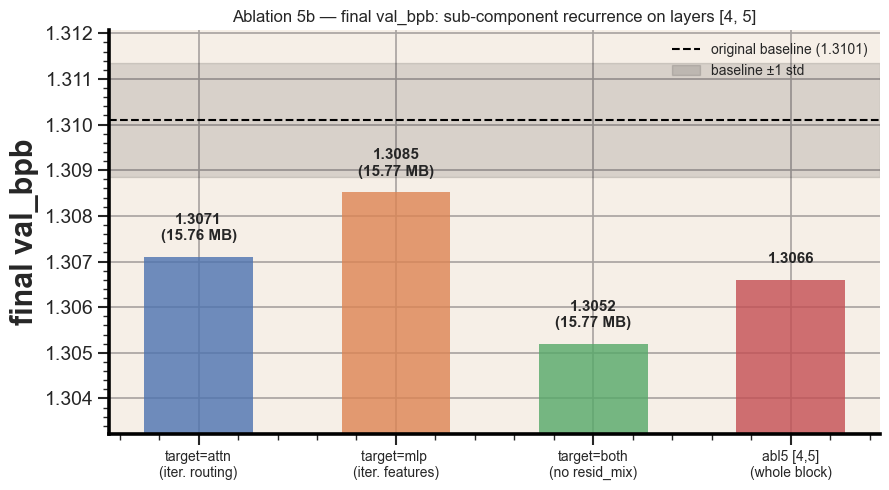

In [11]:
bar_items = []
for t in TARGET_ORDER:
    row = df5b[df5b["recur_target"] == t]
    if row.empty:
        continue
    bar_items.append((TARGET_LABELS[t].replace(" (", "\n("),
                      row["final_val_bpb"].values[0],
                      row["quant_file_bytes"].values[0],
                      TARGET_COLORS[t]))

# ablation-5 reference bar
bar_items.append(("abl5 [4,5]\n(whole block)", abl5_ref_bpb, None, PALETTE[3]))

fig, ax = plt.subplots(figsize=(9, 5))

for i, (label, bpb, qbytes, color) in enumerate(bar_items):
    ax.bar(i, bpb, color=color, alpha=0.80, width=0.55, zorder=2)
    ann = f"{bpb:.4f}"
    if qbytes is not None:
        ann += f"\n({qbytes/1e6:.2f} MB)"
    ax.text(i, bpb + 0.0003, ann, ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"original baseline ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.12, color="black", label="baseline ±1 std")

ax.set_xticks(range(len(bar_items)))
ax.set_xticklabels([it[0] for it in bar_items], fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 5b — final val_bpb: sub-component recurrence on layers [4, 5]")
ax.legend(fontsize=10)

all_bpb = [it[1] for it in bar_items] + [BASE_BPB_MEAN]
pad = (max(all_bpb) - min(all_bpb)) * 0.4
ax.set_ylim(min(all_bpb) - pad, max(all_bpb) + pad)

plt.tight_layout()
plt.show()


### Learning curves — val_bpb and train_loss


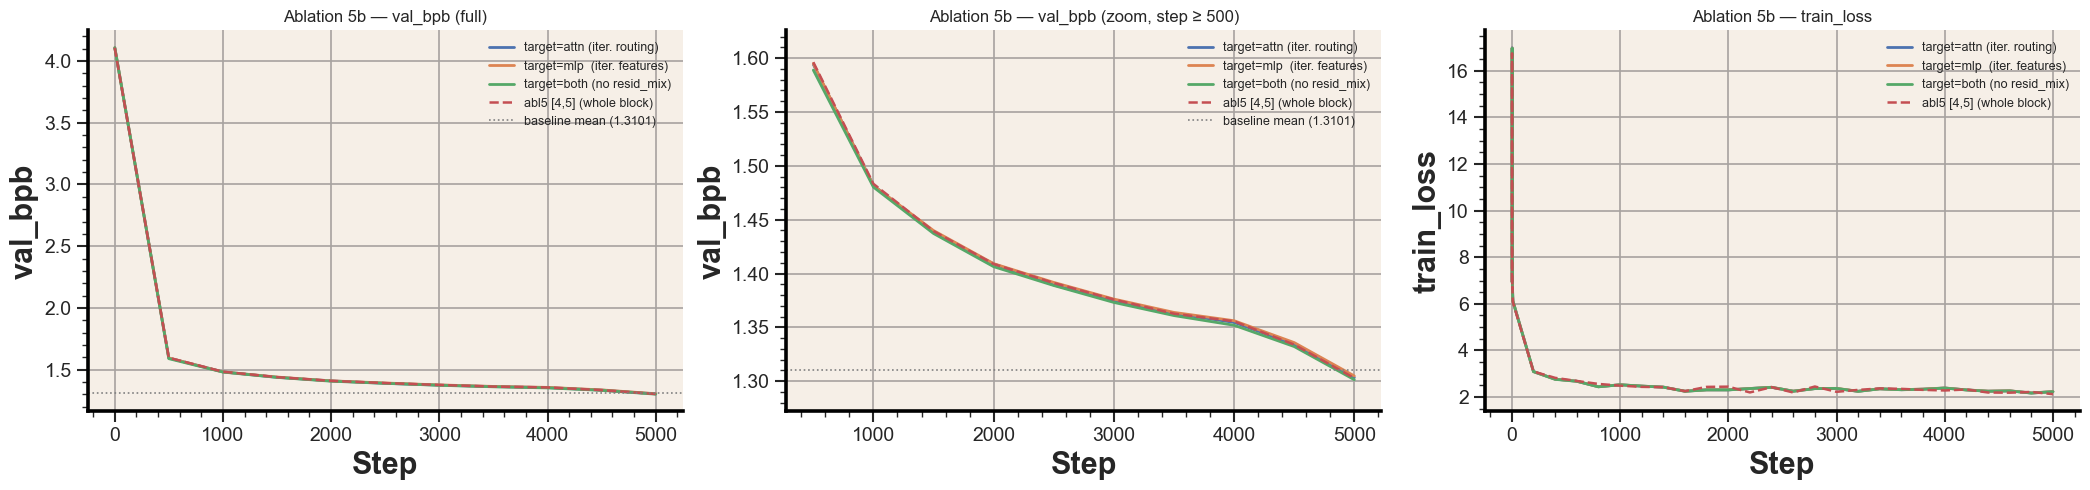

In [12]:
def fetch_5b(runs, metric):
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            t = run.config.get("recur_target")
            histories[t] = hist
    return {t: histories[t] for t in TARGET_ORDER if t in histories}

histories_5b_bpb   = fetch_5b(abl5b_runs, "val_bpb")
histories_5b_train = fetch_5b(abl5b_runs, "train_loss")

# fetch ablation-5 [4, 5] reference series
ref_bpb_hist = None
ref_train_hist = None
for run in abl5_runs:
    if str(sorted(run.config.get("recur_layers", []))) != "[4, 5]":
        continue
    h_bpb = run.history(keys=["_step", "val_bpb"], pandas=True)
    h_tr  = run.history(keys=["_step", "train_loss"], pandas=True)
    if not h_bpb.empty:
        ref_bpb_hist = h_bpb.rename(columns={"_step": "step"}).dropna()
    if not h_tr.empty:
        ref_train_hist = h_tr.rename(columns={"_step": "step"}).dropna()
    break

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# --- full val_bpb ---
ax = axes[0]
for t, hist in histories_5b_bpb.items():
    ax.plot(hist["step"], hist["val_bpb"],
            label=TARGET_LABELS[t], color=TARGET_COLORS[t], linewidth=2)
if ref_bpb_hist is not None:
    ax.plot(ref_bpb_hist["step"], ref_bpb_hist["val_bpb"],
            label="abl5 [4,5] (whole block)", color=PALETTE[3],
            linewidth=1.8, linestyle="--")
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title("Ablation 5b — val_bpb (full)")
ax.legend(fontsize=9)

# --- zoomed val_bpb ---
ax = axes[1]
ZOOM_STEP = 500
for t, hist in histories_5b_bpb.items():
    h = hist[hist["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label=TARGET_LABELS[t], color=TARGET_COLORS[t], linewidth=2)
if ref_bpb_hist is not None:
    h = ref_bpb_hist[ref_bpb_hist["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label="abl5 [4,5] (whole block)", color=PALETTE[3],
            linewidth=1.8, linestyle="--")
all_vals = [h.loc[h["step"] >= ZOOM_STEP, "val_bpb"] for h in histories_5b_bpb.values()]
if ref_bpb_hist is not None:
    all_vals.append(ref_bpb_hist.loc[ref_bpb_hist["step"] >= ZOOM_STEP, "val_bpb"])
ymin = min(v.min() for v in all_vals)
ymax = max(v.max() for v in all_vals)
pad  = (ymax - ymin) * 0.1
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_ylim(min(ymin, BASE_BPB_MEAN) - pad, max(ymax, BASE_BPB_MEAN) + pad)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title(f"Ablation 5b — val_bpb (zoom, step ≥ {ZOOM_STEP})")
ax.legend(fontsize=9)

# --- train_loss ---
ax = axes[2]
for t, hist in histories_5b_train.items():
    ax.plot(hist["step"], hist["train_loss"],
            label=TARGET_LABELS[t], color=TARGET_COLORS[t], linewidth=2)
if ref_train_hist is not None:
    ax.plot(ref_train_hist["step"], ref_train_hist["train_loss"],
            label="abl5 [4,5] (whole block)", color=PALETTE[3],
            linewidth=1.8, linestyle="--")
ax.set_xlabel("Step")
ax.set_ylabel("train_loss")
ax.set_title("Ablation 5b — train_loss")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Generalisation gap — val_loss − train_loss


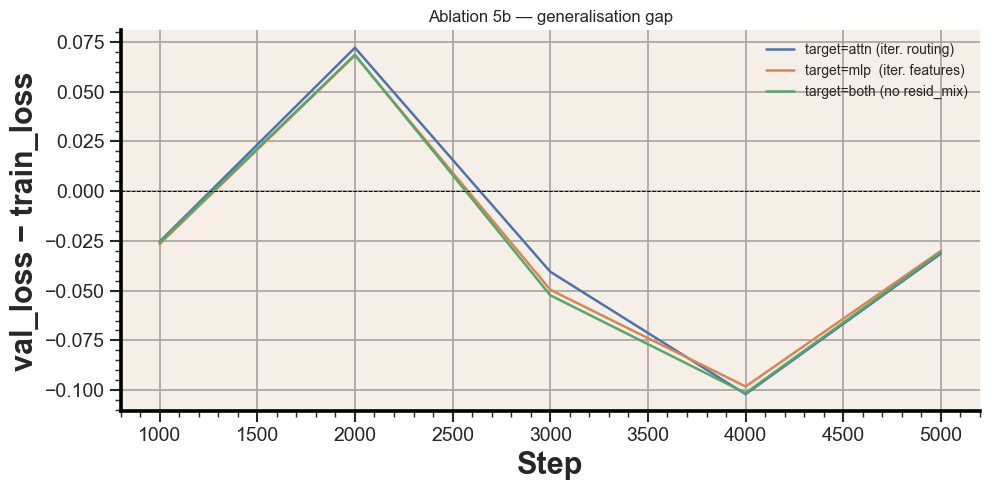

In [13]:
histories_5b_vloss = fetch_5b(abl5b_runs, "val_loss")

fig, ax = plt.subplots(figsize=(10, 5))

for t in TARGET_ORDER:
    if t not in histories_5b_train or t not in histories_5b_vloss:
        continue
    tr = histories_5b_train[t].rename(columns={"train_loss": "tr"})
    vl = histories_5b_vloss[t].rename(columns={"val_loss": "vl"})
    h  = pd.merge(tr, vl, on="step", how="inner")
    ax.plot(h["step"], h["vl"] - h["tr"],
            label=TARGET_LABELS[t], color=TARGET_COLORS[t], linewidth=1.8)

ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_xlabel("Step")
ax.set_ylabel("val_loss − train_loss")
ax.set_title("Ablation 5b — generalisation gap")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Summary — ablation 5b vs all references


In [14]:
rows_summary = [
    {
        "config":          "Original baseline",
        "seeds":           "3",
        "val_bpb":         BASE_BPB_MEAN,
        "val_bpb_std":     BASE_BPB_STD,
        "Δ vs baseline":   0.0,
        "Δ vs abl5 ref":   float("nan"),
    },
    {
        "config":          "abl5 [4,5]  (whole block, ref)",
        "seeds":           "1",
        "val_bpb":         abl5_ref_bpb,
        "val_bpb_std":     float("nan"),
        "Δ vs baseline":   BASE_BPB_MEAN - abl5_ref_bpb,
        "Δ vs abl5 ref":   0.0,
    },
]

for t in TARGET_ORDER:
    row = df5b[df5b["recur_target"] == t]
    if row.empty:
        continue
    bpb = row["final_val_bpb"].values[0]
    rows_summary.append({
        "config":        f"abl5b target={t}",
        "seeds":         "1",
        "val_bpb":       bpb,
        "val_bpb_std":   float("nan"),
        "Δ vs baseline": BASE_BPB_MEAN - bpb,
        "Δ vs abl5 ref": abl5_ref_bpb - bpb,
    })

df_summary5b = pd.DataFrame(rows_summary)
df_summary5b["val_bpb"]       = df_summary5b["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary5b["val_bpb_std"]   = df_summary5b["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary5b["Δ vs baseline"] = df_summary5b["Δ vs baseline"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")
df_summary5b["Δ vs abl5 ref"] = df_summary5b["Δ vs abl5 ref"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")

print(df_summary5b.to_string(index=False))

# verdict
sub_results = {t: df5b.loc[df5b["recur_target"] == t, "final_val_bpb"].values[0]
               for t in TARGET_ORDER if not df5b[df5b["recur_target"] == t].empty}
if sub_results:
    winner = min(sub_results, key=sub_results.get)
    win_bpb = sub_results[winner]
    print(f"\nConclusion: best sub-component recurrence is target={winner} "
          f"({win_bpb:.4f} bpb, {abl5_ref_bpb - win_bpb:+.4f} vs whole-block ref).")


                        config seeds val_bpb val_bpb_std Δ vs baseline Δ vs abl5 ref
             Original baseline     3  1.3101     ±0.0013       +0.0000             —
abl5 [4,5]  (whole block, ref)     1  1.3066           —       +0.0035       +0.0000
             abl5b target=attn     1  1.3071           —       +0.0030       -0.0005
              abl5b target=mlp     1  1.3085           —       +0.0016       -0.0019
             abl5b target=both     1  1.3052           —       +0.0049       +0.0014

Conclusion: best sub-component recurrence is target=both (1.3052 bpb, +0.0014 vs whole-block ref).


---
## Ablation 5c — Combine the layer winner and the recipe winner

Two findings drove this run:

- **From abl5:** layer set `[3, 4]` (straddling the U-Net hinge) outperformed `[4, 5]` by 0.0018 bpb.
- **From abl5b:** `target=both` *without* re-applying `resid_mix` outperformed whole-block recurrence (with `resid_mix`) by 0.0014 bpb on `[4, 5]`.

Ablation 5c crosses the two, plus a wider variant matching the top leaderboard entries:

| config | meaning |
|---|---|
| `[3, 4]`     | A — layer winner × target winner |
| `[3, 4, 5]`  | B — extend to 3 layers (matches top leaderboard entries) |

Both runs use `target=both`, `recur_times=1`, `seed=1337`, identical 5 000-step budget.


In [15]:
ABL5C_PREFIX = "ablation5c_"

abl5c_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL5C_PREFIX}"}},
))

ABL5C_ORDER  = ["[3, 4]", "[3, 4, 5]"]
ABL5C_LABELS = {
    "[3, 4]":    "5c-A: both [3,4]",
    "[3, 4, 5]": "5c-B: both [3,4,5]",
}
ABL5C_COLORS = {ABL5C_ORDER[0]: PALETTE[4], ABL5C_ORDER[1]: PALETTE[5]}

abl5c_rows = []
for run in abl5c_runs:
    s   = run.summary._json_dict
    cfg = run.config
    layers = str(sorted(cfg.get("recur_layers", [])))
    abl5c_rows.append({
        "run_name":         run.name,
        "recur_layers":     layers,
        "label":            ABL5C_LABELS.get(layers, layers),
        "recur_target":     cfg.get("recur_target"),
        "recur_times":      cfg.get("recur_times", 1),
        "seed":             cfg.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df5c = (
    pd.DataFrame(abl5c_rows)
    .assign(order=lambda d: d["recur_layers"].map({v: i for i, v in enumerate(ABL5C_ORDER)}))
    .sort_values("order")
    .reset_index(drop=True)
    .drop(columns="order")
)

print("=" * 70)
print("ABLATION 5c — combined layer + recipe winners (target=both)")
print("=" * 70)
print(df5c[["label", "recur_layers", "recur_target", "seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].to_string(index=False))
print(f"\nReferences:")
print(f"  Original baseline (3-seed mean) : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")
print(f"  abl5 [3, 4] (whole block)       : {df.loc[df['recur_layers'] == '[3, 4]', 'final_val_bpb'].values[0]:.4f} bpb")
print(f"  abl5b both [4, 5]               : {df5b.loc[df5b['recur_target'] == 'both', 'final_val_bpb'].values[0]:.4f} bpb")
print("=" * 70)


ABLATION 5c — combined layer + recipe winners (target=both)
             label recur_layers recur_target  seed  final_val_bpb  final_val_loss  quant_file_bytes
  5c-A: both [3,4]       [3, 4]         both  1337       1.304378        2.202388          15758096
5c-B: both [3,4,5]    [3, 4, 5]         both  1337       1.302883        2.199863          15760340

References:
  Original baseline (3-seed mean) : 1.3101 ± 0.0013 bpb
  abl5 [3, 4] (whole block)       : 1.3048 bpb
  abl5b both [4, 5]               : 1.3052 bpb


### Final val_bpb — 5c vs all references


/var/folders/l5/zqrq9w6x6zd5jpy3m6n7t60m0000gp/T/ipykernel_12936/3576089737.py:53: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/antonio2/miniforge3/envs/edln/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


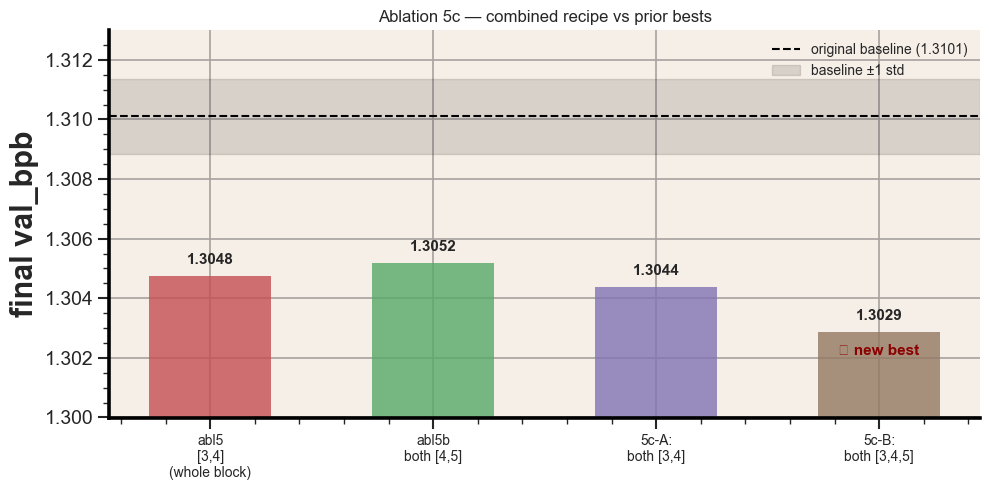

In [16]:
abl5_ref_34   = df.loc[df['recur_layers'] == '[3, 4]', 'final_val_bpb'].values[0]
abl5_ref_45   = df.loc[df['recur_layers'] == '[4, 5]', 'final_val_bpb'].values[0]
abl5b_ref_both = df5b.loc[df5b['recur_target'] == 'both', 'final_val_bpb'].values[0]

bar_items = [
    ("abl5\n[3,4]\n(whole block)",   abl5_ref_34,   PALETTE[3]),
    ("abl5b\nboth [4,5]",             abl5b_ref_both, PALETTE[2]),
]
for layers in ABL5C_ORDER:
    row = df5c[df5c["recur_layers"] == layers]
    if row.empty:
        continue
    bar_items.append((ABL5C_LABELS[layers].replace(": ", ":\n"),
                      row["final_val_bpb"].values[0],
                      ABL5C_COLORS[layers]))

fig, ax = plt.subplots(figsize=(10, 5))

for i, (label, bpb, color) in enumerate(bar_items):
    ax.bar(i, bpb, color=color, alpha=0.80, width=0.55, zorder=2)
    ax.text(i, bpb + 0.0003, f"{bpb:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"original baseline ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.12, color="black", label="baseline ±1 std")

# best 5c bar gets a star annotation
best_5c_idx = max(range(len(bar_items)), key=lambda i: -bar_items[i][1] if bar_items[i][0].startswith("5c") else float("inf"))
# (we want min bpb among 5c bars)
best_5c_idx = None
best_5c_bpb = float("inf")
for i, (label, bpb, _) in enumerate(bar_items):
    if label.startswith("5c") and bpb < best_5c_bpb:
        best_5c_bpb = bpb
        best_5c_idx = i
if best_5c_idx is not None:
    ax.annotate("★ new best", xy=(best_5c_idx, bar_items[best_5c_idx][1]),
                xytext=(best_5c_idx, bar_items[best_5c_idx][1] - 0.0008),
                ha="center", fontsize=11, fontweight="bold", color="darkred")

ax.set_xticks(range(len(bar_items)))
ax.set_xticklabels([it[0] for it in bar_items], fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 5c — combined recipe vs prior bests")
ax.legend(fontsize=10, loc="upper right")

all_bpb = [it[1] for it in bar_items] + [BASE_BPB_MEAN]
pad = (max(all_bpb) - min(all_bpb)) * 0.4
ax.set_ylim(min(all_bpb) - pad, max(all_bpb) + pad)

plt.tight_layout()
plt.show()


### Learning curves — does the wider recurrence converge differently?

We overlay 5c-A and 5c-B against the abl5 `[3, 4]` reference (whole-block recurrence). If 5c-B sits below 5c-A throughout, the 3-layer recurrence is genuinely better; if it only wins at the end, it may just be exploiting the warmdown more aggressively.


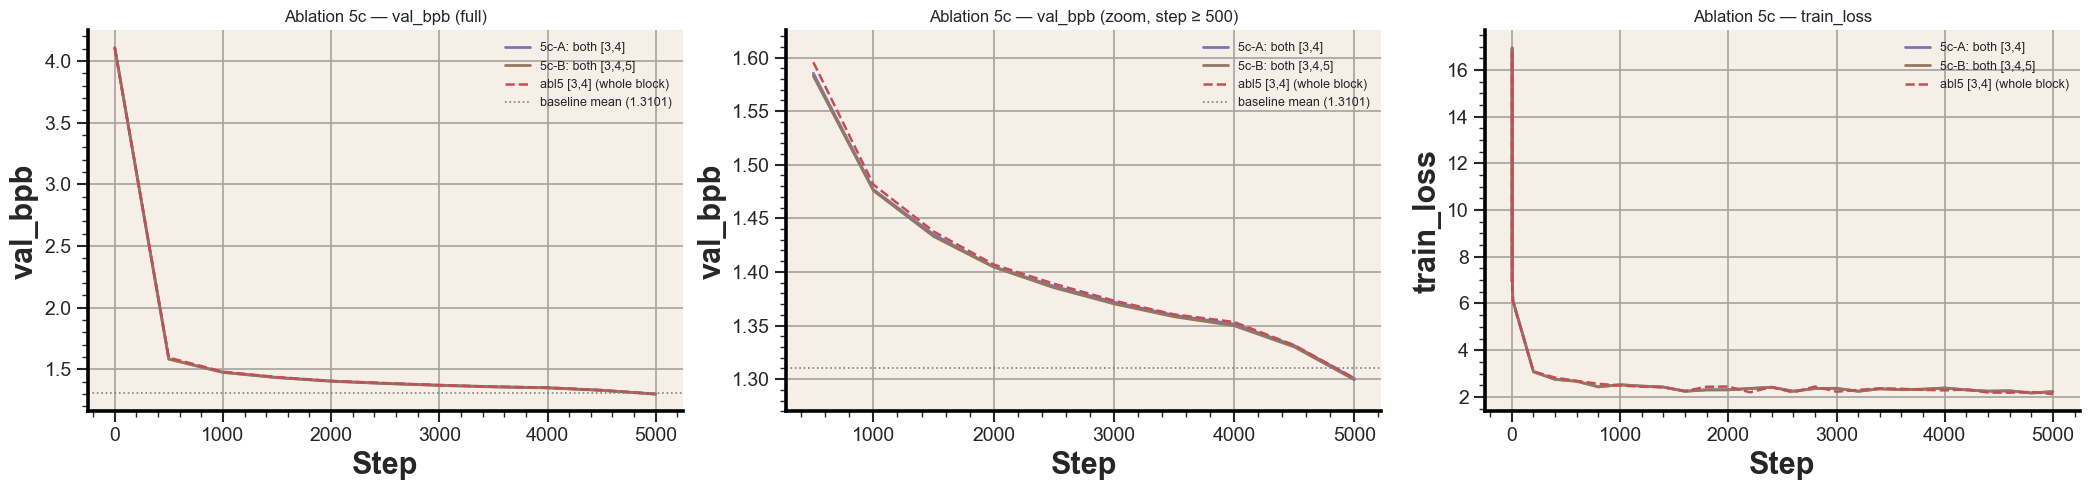

In [17]:
def fetch_5c(runs, metric):
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            layers = str(sorted(run.config.get("recur_layers", [])))
            histories[layers] = hist
    return {k: histories[k] for k in ABL5C_ORDER if k in histories}

histories_5c_bpb   = fetch_5c(abl5c_runs, "val_bpb")
histories_5c_train = fetch_5c(abl5c_runs, "train_loss")

# abl5 [3,4] reference
ref_34_bpb = None
ref_34_train = None
for run in abl5_runs:
    if str(sorted(run.config.get("recur_layers", []))) != "[3, 4]":
        continue
    h_b  = run.history(keys=["_step", "val_bpb"], pandas=True)
    h_t  = run.history(keys=["_step", "train_loss"], pandas=True)
    if not h_b.empty:
        ref_34_bpb = h_b.rename(columns={"_step": "step"}).dropna()
    if not h_t.empty:
        ref_34_train = h_t.rename(columns={"_step": "step"}).dropna()
    break

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# --- full val_bpb ---
ax = axes[0]
for k, hist in histories_5c_bpb.items():
    ax.plot(hist["step"], hist["val_bpb"],
            label=ABL5C_LABELS[k], color=ABL5C_COLORS[k], linewidth=2)
if ref_34_bpb is not None:
    ax.plot(ref_34_bpb["step"], ref_34_bpb["val_bpb"],
            label="abl5 [3,4] (whole block)", color=PALETTE[3],
            linewidth=1.8, linestyle="--")
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title("Ablation 5c — val_bpb (full)")
ax.legend(fontsize=9)

# --- zoomed val_bpb ---
ax = axes[1]
ZOOM_STEP = 500
for k, hist in histories_5c_bpb.items():
    h = hist[hist["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label=ABL5C_LABELS[k], color=ABL5C_COLORS[k], linewidth=2)
if ref_34_bpb is not None:
    h = ref_34_bpb[ref_34_bpb["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label="abl5 [3,4] (whole block)", color=PALETTE[3],
            linewidth=1.8, linestyle="--")
all_vals = [h.loc[h["step"] >= ZOOM_STEP, "val_bpb"] for h in histories_5c_bpb.values()]
if ref_34_bpb is not None:
    all_vals.append(ref_34_bpb.loc[ref_34_bpb["step"] >= ZOOM_STEP, "val_bpb"])
ymin = min(v.min() for v in all_vals)
ymax = max(v.max() for v in all_vals)
pad  = (ymax - ymin) * 0.1
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_ylim(min(ymin, BASE_BPB_MEAN) - pad, max(ymax, BASE_BPB_MEAN) + pad)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title(f"Ablation 5c — val_bpb (zoom, step ≥ {ZOOM_STEP})")
ax.legend(fontsize=9)

# --- train_loss ---
ax = axes[2]
for k, hist in histories_5c_train.items():
    ax.plot(hist["step"], hist["train_loss"],
            label=ABL5C_LABELS[k], color=ABL5C_COLORS[k], linewidth=2)
if ref_34_train is not None:
    ax.plot(ref_34_train["step"], ref_34_train["train_loss"],
            label="abl5 [3,4] (whole block)", color=PALETTE[3],
            linewidth=1.8, linestyle="--")
ax.set_xlabel("Step")
ax.set_ylabel("train_loss")
ax.set_title("Ablation 5c — train_loss")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Final summary — full progression


In [18]:
rows_summary = [
    {"config": "Original baseline",                "seeds": "3", "val_bpb": BASE_BPB_MEAN, "val_bpb_std": BASE_BPB_STD, "Δ vs baseline": 0.0},
]

# ablation 5
for k in RECUR_ORDER:
    sub = df[df["recur_layers"] == k]
    if sub.empty:
        continue
    bpb = sub["final_val_bpb"].values[0]
    rows_summary.append({
        "config":        f"abl5  {k} whole-block",
        "seeds":         "1",
        "val_bpb":       bpb,
        "val_bpb_std":   float("nan"),
        "Δ vs baseline": BASE_BPB_MEAN - bpb,
    })

# ablation 5b
for t in TARGET_ORDER:
    sub = df5b[df5b["recur_target"] == t]
    if sub.empty:
        continue
    bpb = sub["final_val_bpb"].values[0]
    rows_summary.append({
        "config":        f"abl5b target={t} [4, 5]",
        "seeds":         "1",
        "val_bpb":       bpb,
        "val_bpb_std":   float("nan"),
        "Δ vs baseline": BASE_BPB_MEAN - bpb,
    })

# ablation 5c
for k in ABL5C_ORDER:
    sub = df5c[df5c["recur_layers"] == k]
    if sub.empty:
        continue
    bpb = sub["final_val_bpb"].values[0]
    rows_summary.append({
        "config":        f"abl5c both {k}",
        "seeds":         "1",
        "val_bpb":       bpb,
        "val_bpb_std":   float("nan"),
        "Δ vs baseline": BASE_BPB_MEAN - bpb,
    })

df_full = pd.DataFrame(rows_summary).sort_values("val_bpb").reset_index(drop=True)
df_full["val_bpb"]       = df_full["val_bpb"].map(lambda x: f"{x:.4f}")
df_full["val_bpb_std"]   = df_full["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_full["Δ vs baseline"] = df_full["Δ vs baseline"].map(lambda x: f"{x:+.4f}" if not np.isnan(x) else "—")

print(df_full.to_string(index=False))

# verdict
best_bpb = min(float(s.split("±")[0].strip()) if "±" in s else float(s) for s in df_full["val_bpb"])
best_row = df_full[df_full["val_bpb"].apply(lambda s: float(s.split('±')[0].strip()) if '±' in s else float(s)) == best_bpb].iloc[0]
print(f"\n★ New best:  {best_row['config']}  →  {best_row['val_bpb']} bpb  ({best_row['Δ vs baseline']} vs baseline)")


                  config seeds val_bpb val_bpb_std Δ vs baseline
    abl5c both [3, 4, 5]     1  1.3029           —       +0.0072
       abl5c both [3, 4]     1  1.3044           —       +0.0057
abl5  [3, 4] whole-block     1  1.3048           —       +0.0053
abl5b target=both [4, 5]     1  1.3052           —       +0.0049
abl5  [4, 5] whole-block     1  1.3066           —       +0.0035
abl5b target=attn [4, 5]     1  1.3071           —       +0.0030
   abl5  [4] whole-block     1  1.3076           —       +0.0025
 abl5b target=mlp [4, 5]     1  1.3085           —       +0.0016
       Original baseline     3  1.3101     ±0.0013       +0.0000
abl5  [5, 6] whole-block     1  1.3103           —       -0.0002

★ New best:  abl5c both [3, 4, 5]  →  1.3029 bpb  (+0.0072 vs baseline)


---
## Ablation 5d — Sweep the recurrence horizon

5c-B established `[3, 4, 5]` (3 layers, `target=both`) as the best configuration so far. The horizon clearly hadn't saturated — going from 1→2→3 layers each helped meaningfully. Ablation 5d tests both directions of extension:

| config | direction | meaning |
|---|---|---|
| `[3, 4, 5, 6]` | extend deeper into decoder | does 4 layers continue the trend on the decoder side? |
| `[2, 3, 4, 5]` | extend back into encoder | is the encoder side useful, or is the win specifically about straddling the U-Net hinge from below? |

Both runs use `target=both`, `recur_times=1`, seed 1337, identical 5 000-step budget.


In [19]:
ABL5D_PREFIX = "ablation5d_"

abl5d_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL5D_PREFIX}"}},
))

ABL5D_ORDER  = ["[2, 3, 4, 5]", "[3, 4, 5, 6]"]
ABL5D_LABELS = {
    "[2, 3, 4, 5]": "5d-B: both [2,3,4,5] (encoder ext.)",
    "[3, 4, 5, 6]": "5d-A: both [3,4,5,6] (decoder ext.)",
}
ABL5D_COLORS = {ABL5D_ORDER[0]: "#17becf", ABL5D_ORDER[1]: "#e377c2"}

abl5d_rows = []
for run in abl5d_runs:
    s   = run.summary._json_dict
    cfg = run.config
    layers = str(sorted(cfg.get("recur_layers", [])))
    abl5d_rows.append({
        "run_name":         run.name,
        "recur_layers":     layers,
        "label":            ABL5D_LABELS.get(layers, layers),
        "recur_target":     cfg.get("recur_target"),
        "recur_times":      cfg.get("recur_times", 1),
        "seed":             cfg.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df5d = (
    pd.DataFrame(abl5d_rows)
    .assign(order=lambda d: d["recur_layers"].map({v: i for i, v in enumerate(ABL5D_ORDER)}))
    .sort_values("order")
    .reset_index(drop=True)
    .drop(columns="order")
)

print("=" * 70)
print("ABLATION 5d — horizon sweep (target=both, seed=1337)")
print("=" * 70)
print(df5d[["label", "recur_layers", "recur_target", "seed", "final_val_bpb", "final_val_loss", "quant_file_bytes"]].to_string(index=False))
print(f"\nReferences:")
print(f"  Original baseline (3-seed mean) : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")
print(f"  abl5c-B [3, 4, 5] target=both   : {df5c.loc[df5c['recur_layers'] == '[3, 4, 5]', 'final_val_bpb'].values[0]:.4f} bpb (prev best)")
print("=" * 70)


ABLATION 5d — horizon sweep (target=both, seed=1337)
                              label recur_layers recur_target  seed  final_val_bpb  final_val_loss  quant_file_bytes
5d-B: both [2,3,4,5] (encoder ext.) [2, 3, 4, 5]         both  1337       1.301027        2.196729          15754880
5d-A: both [3,4,5,6] (decoder ext.) [3, 4, 5, 6]         both  1337       1.302576        2.199345          15766876

References:
  Original baseline (3-seed mean) : 1.3101 ± 0.0013 bpb
  abl5c-B [3, 4, 5] target=both   : 1.3029 bpb (prev best)


### Final val_bpb — horizon sweep vs all prior depth-recurrence bests


/var/folders/l5/zqrq9w6x6zd5jpy3m6n7t60m0000gp/T/ipykernel_12936/3249300886.py:45: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/antonio2/miniforge3/envs/edln/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


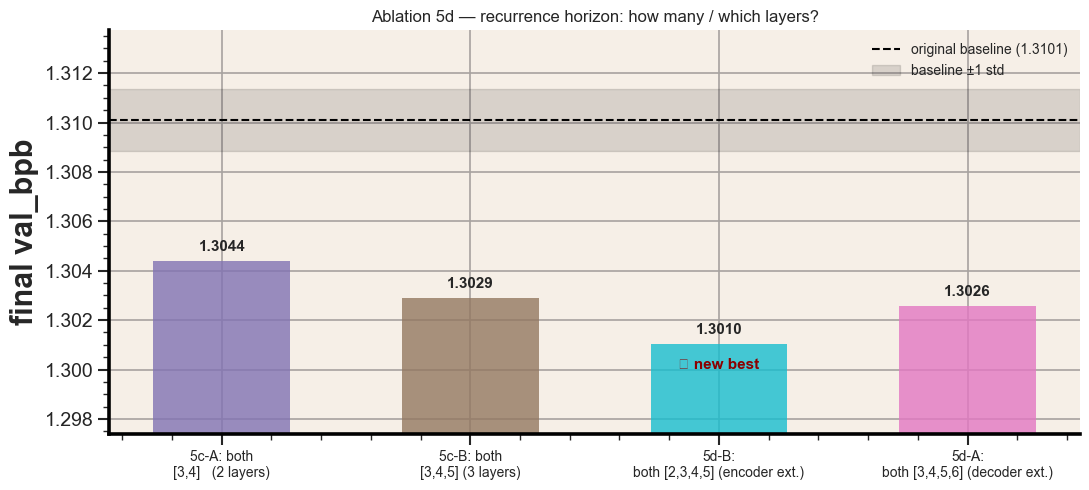

In [20]:
abl5c_b_bpb = df5c.loc[df5c["recur_layers"] == "[3, 4, 5]", "final_val_bpb"].values[0]
abl5c_a_bpb = df5c.loc[df5c["recur_layers"] == "[3, 4]",    "final_val_bpb"].values[0]

bar_items = [
    ("5c-A: both\n[3,4]   (2 layers)",     abl5c_a_bpb, PALETTE[4]),
    ("5c-B: both\n[3,4,5] (3 layers)",     abl5c_b_bpb, PALETTE[5]),
]
for layers in ABL5D_ORDER:
    row = df5d[df5d["recur_layers"] == layers]
    if row.empty:
        continue
    bar_items.append((ABL5D_LABELS[layers].replace(": both ", ":\nboth "),
                      row["final_val_bpb"].values[0],
                      ABL5D_COLORS[layers]))

fig, ax = plt.subplots(figsize=(11, 5))

for i, (label, bpb, color) in enumerate(bar_items):
    ax.bar(i, bpb, color=color, alpha=0.80, width=0.55, zorder=2)
    ax.text(i, bpb + 0.0003, f"{bpb:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"original baseline ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.12, color="black", label="baseline ±1 std")

# annotate the best bar with a star
best_idx = min(range(len(bar_items)), key=lambda i: bar_items[i][1])
ax.annotate("★ new best",
            xy=(best_idx, bar_items[best_idx][1]),
            xytext=(best_idx, bar_items[best_idx][1] - 0.0010),
            ha="center", fontsize=11, fontweight="bold", color="darkred")

ax.set_xticks(range(len(bar_items)))
ax.set_xticklabels([it[0] for it in bar_items], fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 5d — recurrence horizon: how many / which layers?")
ax.legend(fontsize=10, loc="upper right")

all_bpb = [it[1] for it in bar_items] + [BASE_BPB_MEAN]
pad = (max(all_bpb) - min(all_bpb)) * 0.4
ax.set_ylim(min(all_bpb) - pad, max(all_bpb) + pad)

plt.tight_layout()
plt.show()


### Horizon trend — bpb vs number of recurred layers (window position annotated)

A clearer view of the scaling: x-axis is number of recurred layers, marker labels show *which* layers. Encoder-side and decoder-side extensions are colour-coded.


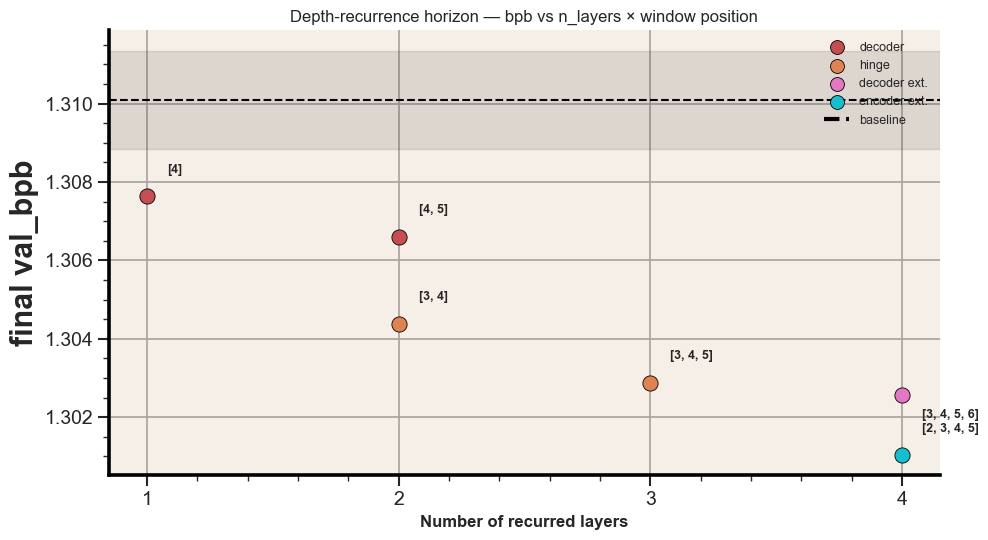

In [21]:
# All target=both runs we have, organised by (n_layers, window_anchor)
horizon_points = [
    ("[4]",         1, "decoder",  df.loc[df["recur_layers"] == "[4]",     "final_val_bpb"].values[0]),
    ("[4, 5]",      2, "decoder",  df.loc[df["recur_layers"] == "[4, 5]",  "final_val_bpb"].values[0]),
    ("[3, 4]",      2, "hinge",    abl5c_a_bpb),
    ("[3, 4, 5]",   3, "hinge",    abl5c_b_bpb),
    ("[3, 4, 5, 6]",4, "decoder ext.",
        df5d.loc[df5d["recur_layers"] == "[3, 4, 5, 6]", "final_val_bpb"].values[0] if not df5d[df5d["recur_layers"] == "[3, 4, 5, 6]"].empty else float("nan")),
    ("[2, 3, 4, 5]",4, "encoder ext.",
        df5d.loc[df5d["recur_layers"] == "[2, 3, 4, 5]", "final_val_bpb"].values[0] if not df5d[df5d["recur_layers"] == "[2, 3, 4, 5]"].empty else float("nan")),
]

direction_colors = {
    "decoder":      PALETTE[3],
    "hinge":        PALETTE[1],
    "decoder ext.": "#e377c2",
    "encoder ext.": "#17becf",
}

fig, ax = plt.subplots(figsize=(10, 5.5))

for label, n, direction, bpb in horizon_points:
    color = direction_colors.get(direction, "grey")
    ax.scatter(n, bpb, s=120, color=color, edgecolor="black", linewidths=0.6, zorder=3)
    # offset labels to avoid overlap
    dy = -0.0006 if direction == "decoder ext." else 0.0006
    ax.annotate(label, xy=(n, bpb), xytext=(n + 0.08, bpb + dy),
                fontsize=9, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.10, color="black")

# legend by direction
handles = [plt.scatter([], [], s=100, color=c, edgecolor="black", linewidths=0.6, label=d)
           for d, c in direction_colors.items()]
handles.append(plt.Line2D([], [], color="black", linestyle="--", label=f"baseline"))
ax.legend(handles=handles, fontsize=9, loc="upper right")

ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel("Number of recurred layers", fontsize=12, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Depth-recurrence horizon — bpb vs n_layers × window position")
plt.tight_layout()
plt.show()


### Learning curves — does encoder extension change the trajectory?


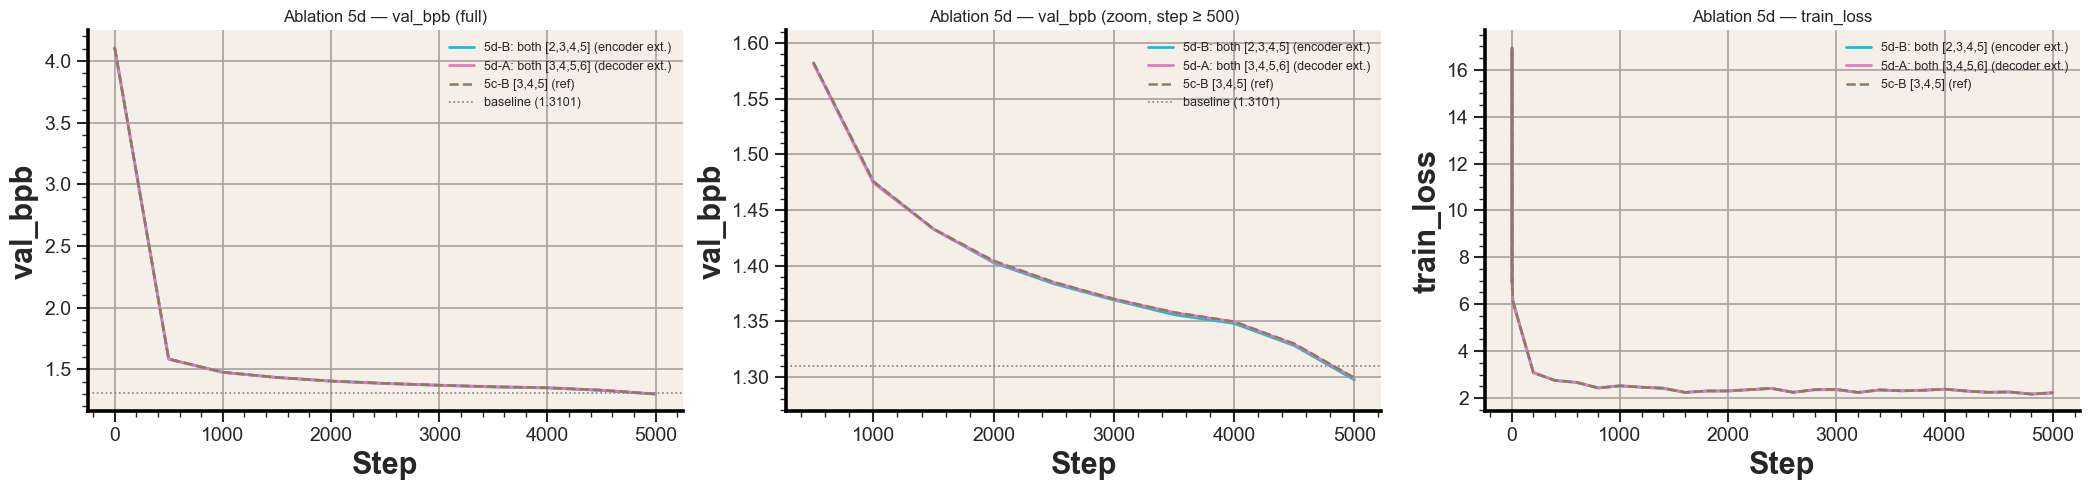

In [22]:
def fetch_5d(runs, metric):
    histories = {}
    for run in runs:
        hist = run.history(keys=["_step", metric], pandas=True)
        if not hist.empty:
            hist = hist.rename(columns={"_step": "step"}).dropna()
            layers = str(sorted(run.config.get("recur_layers", [])))
            histories[layers] = hist
    return {k: histories[k] for k in ABL5D_ORDER if k in histories}

histories_5d_bpb   = fetch_5d(abl5d_runs, "val_bpb")
histories_5d_train = fetch_5d(abl5d_runs, "train_loss")

# 5c-B reference history
ref_5cb_bpb = None
ref_5cb_train = None
for run in abl5c_runs:
    if str(sorted(run.config.get("recur_layers", []))) != "[3, 4, 5]":
        continue
    h_b = run.history(keys=["_step", "val_bpb"], pandas=True)
    h_t = run.history(keys=["_step", "train_loss"], pandas=True)
    if not h_b.empty:
        ref_5cb_bpb = h_b.rename(columns={"_step": "step"}).dropna()
    if not h_t.empty:
        ref_5cb_train = h_t.rename(columns={"_step": "step"}).dropna()
    break

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# --- full val_bpb ---
ax = axes[0]
for k, hist in histories_5d_bpb.items():
    ax.plot(hist["step"], hist["val_bpb"],
            label=ABL5D_LABELS[k], color=ABL5D_COLORS[k], linewidth=2)
if ref_5cb_bpb is not None:
    ax.plot(ref_5cb_bpb["step"], ref_5cb_bpb["val_bpb"],
            label="5c-B [3,4,5] (ref)", color=PALETTE[5],
            linewidth=1.8, linestyle="--")
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title("Ablation 5d — val_bpb (full)")
ax.legend(fontsize=9)

# --- zoomed val_bpb ---
ax = axes[1]
ZOOM_STEP = 500
for k, hist in histories_5d_bpb.items():
    h = hist[hist["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label=ABL5D_LABELS[k], color=ABL5D_COLORS[k], linewidth=2)
if ref_5cb_bpb is not None:
    h = ref_5cb_bpb[ref_5cb_bpb["step"] >= ZOOM_STEP]
    ax.plot(h["step"], h["val_bpb"],
            label="5c-B [3,4,5] (ref)", color=PALETTE[5],
            linewidth=1.8, linestyle="--")
all_vals = [h.loc[h["step"] >= ZOOM_STEP, "val_bpb"] for h in histories_5d_bpb.values()]
if ref_5cb_bpb is not None:
    all_vals.append(ref_5cb_bpb.loc[ref_5cb_bpb["step"] >= ZOOM_STEP, "val_bpb"])
ymin = min(v.min() for v in all_vals)
ymax = max(v.max() for v in all_vals)
pad  = (ymax - ymin) * 0.1
ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_ylim(min(ymin, BASE_BPB_MEAN) - pad, max(ymax, BASE_BPB_MEAN) + pad)
ax.set_xlabel("Step")
ax.set_ylabel("val_bpb")
ax.set_title(f"Ablation 5d — val_bpb (zoom, step ≥ {ZOOM_STEP})")
ax.legend(fontsize=9)

# --- train_loss ---
ax = axes[2]
for k, hist in histories_5d_train.items():
    ax.plot(hist["step"], hist["train_loss"],
            label=ABL5D_LABELS[k], color=ABL5D_COLORS[k], linewidth=2)
if ref_5cb_train is not None:
    ax.plot(ref_5cb_train["step"], ref_5cb_train["train_loss"],
            label="5c-B [3,4,5] (ref)", color=PALETTE[5],
            linewidth=1.8, linestyle="--")
ax.set_xlabel("Step")
ax.set_ylabel("train_loss")
ax.set_title("Ablation 5d — train_loss")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### Final summary — full depth-recurrence progression


In [23]:
rows_summary = [
    {"config": "Original baseline", "seeds": "3", "val_bpb": BASE_BPB_MEAN, "Δ vs baseline": 0.0},
]
for k in RECUR_ORDER:
    sub = df[df["recur_layers"] == k]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5  {k} whole-block", "seeds": "1",
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0]})
for t in TARGET_ORDER:
    sub = df5b[df5b["recur_target"] == t]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5b target={t} [4, 5]", "seeds": "1",
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0]})
for k in ABL5C_ORDER:
    sub = df5c[df5c["recur_layers"] == k]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5c both {k}", "seeds": "1",
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0]})
for k in ABL5D_ORDER:
    sub = df5d[df5d["recur_layers"] == k]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5d both {k}", "seeds": "1",
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0]})

df_full = pd.DataFrame(rows_summary).sort_values("val_bpb").reset_index(drop=True)
df_full["val_bpb"]       = df_full["val_bpb"].map(lambda x: f"{x:.4f}")
df_full["Δ vs baseline"] = df_full["Δ vs baseline"].map(lambda x: f"{x:+.4f}")

print(df_full.to_string(index=False))

best_row = df_full.iloc[0]
print(f"\n★ Current best: {best_row['config']}  →  {best_row['val_bpb']} bpb  ({best_row['Δ vs baseline']} vs baseline)")


                  config seeds val_bpb Δ vs baseline
 abl5d both [2, 3, 4, 5]     1  1.3010       +0.0091
 abl5d both [3, 4, 5, 6]     1  1.3026       +0.0075
    abl5c both [3, 4, 5]     1  1.3029       +0.0072
       abl5c both [3, 4]     1  1.3044       +0.0057
abl5  [3, 4] whole-block     1  1.3048       +0.0053
abl5b target=both [4, 5]     1  1.3052       +0.0049
abl5  [4, 5] whole-block     1  1.3066       +0.0035
abl5b target=attn [4, 5]     1  1.3071       +0.0030
   abl5  [4] whole-block     1  1.3076       +0.0025
 abl5b target=mlp [4, 5]     1  1.3085       +0.0016
       Original baseline     3  1.3101       +0.0000
abl5  [5, 6] whole-block     1  1.3103       -0.0002

★ Current best: abl5d both [2, 3, 4, 5]  →  1.3010 bpb  (+0.0091 vs baseline)


---
## Ablation 5e — Push the horizon to 5 layers

5d showed that encoder-side extension `[2, 3, 4, 5]` (1.3010) decisively beat decoder-side extension `[3, 4, 5, 6]` (1.3026), so the trend "encoder-side recurrence helps more than deeper decoder recurrence" had clear momentum. Ablation 5e tests whether that trend continues at 5 layers:

| config | meaning |
|---|---|
| `[1, 2, 3, 4, 5]` | one more encoder-side step — does the encoder trend keep paying? |
| `[2, 3, 4, 5, 6]` | combine encoder-side win with decoder-side extension — do they add? |

Both runs use `target=both`, `recur_times=1`, seed 1337, identical 5 000-step budget.


In [24]:
ABL5E_PREFIX = "ablation5e_"

abl5e_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL5E_PREFIX}"}},
))

ABL5E_ORDER  = ["[1, 2, 3, 4, 5]", "[2, 3, 4, 5, 6]"]
ABL5E_LABELS = {
    "[1, 2, 3, 4, 5]": "5e-A: both [1,2,3,4,5] (encoder ext.)",
    "[2, 3, 4, 5, 6]": "5e-B: both [2,3,4,5,6] (combined ext.)",
}
ABL5E_COLORS = {ABL5E_ORDER[0]: "#bcbd22",
                ABL5E_ORDER[1]: "#7f7f7f"}

abl5e_rows = []
for run in abl5e_runs:
    s   = run.summary._json_dict
    cfg = run.config
    layers = str(sorted(cfg.get("recur_layers", [])))
    abl5e_rows.append({
        "run_name":         run.name,
        "recur_layers":     layers,
        "label":            ABL5E_LABELS.get(layers, layers),
        "recur_target":     cfg.get("recur_target"),
        "recur_times":      cfg.get("recur_times", 1),
        "seed":             cfg.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
        "runtime_min":      (s.get("_runtime") or 0) / 60.0,
    })

df5e = (
    pd.DataFrame(abl5e_rows)
    .assign(order=lambda d: d["recur_layers"].map({v: i for i, v in enumerate(ABL5E_ORDER)}))
    .sort_values("order")
    .reset_index(drop=True)
    .drop(columns="order")
)

abl5d_b_bpb = df5d.loc[df5d["recur_layers"] == "[2, 3, 4, 5]", "final_val_bpb"].values[0]

print("=" * 75)
print("ABLATION 5e — push horizon to 5 layers (target=both, seed=1337)")
print("=" * 75)
print(df5e[["label", "recur_layers", "seed", "final_val_bpb", "final_val_loss", "runtime_min"]].to_string(index=False))
print(f"\nReferences:")
print(f"  Original baseline (3-seed mean) : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")
print(f"  abl5d-B [2, 3, 4, 5] (4 layers) : {abl5d_b_bpb:.4f} bpb (prev best)")

for layers in ABL5E_ORDER:
    sub = df5e[df5e["recur_layers"] == layers]
    if sub.empty: continue
    bpb = sub["final_val_bpb"].values[0]
    delta = abl5d_b_bpb - bpb
    print(f"  {layers}  Δ vs 5d-B: {delta:+.4f} bpb")
print("=" * 75)


ABLATION 5e — push horizon to 5 layers (target=both, seed=1337)
                                 label    recur_layers  seed  final_val_bpb  final_val_loss  runtime_min
 5e-A: both [1,2,3,4,5] (encoder ext.) [1, 2, 3, 4, 5]  1337       1.300524        2.195880    64.966667
5e-B: both [2,3,4,5,6] (combined ext.) [2, 3, 4, 5, 6]  1337       1.300572        2.195962    64.700000

References:
  Original baseline (3-seed mean) : 1.3101 ± 0.0013 bpb
  abl5d-B [2, 3, 4, 5] (4 layers) : 1.3010 bpb (prev best)
  [1, 2, 3, 4, 5]  Δ vs 5d-B: +0.0005 bpb
  [2, 3, 4, 5, 6]  Δ vs 5d-B: +0.0005 bpb


### Final val_bpb — full horizon picture (1 → 5 layers)


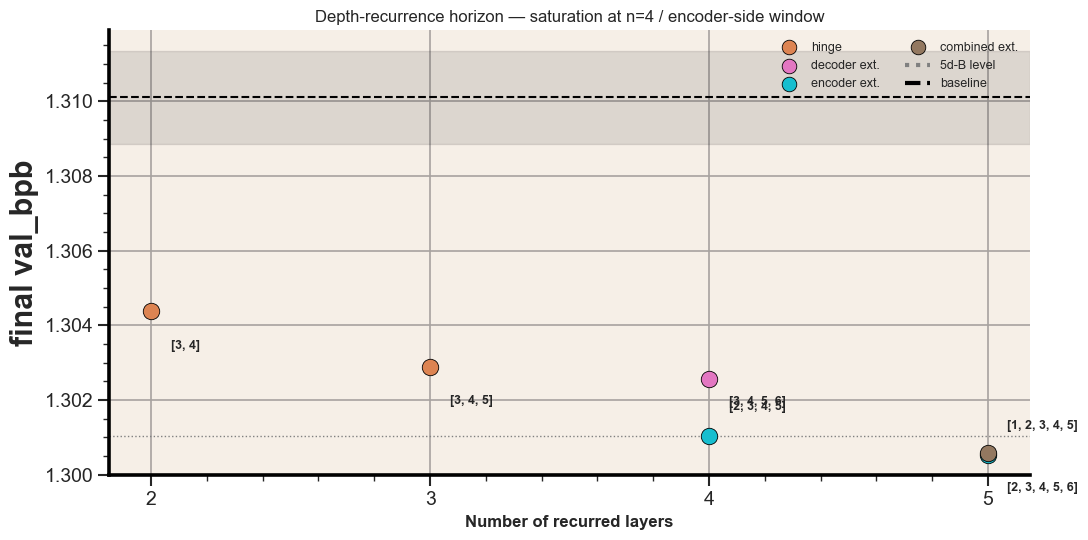

In [25]:
# Build a unified horizon view across all `target=both` runs
horizon_data = [
    ("[3, 4]",         abl5c_a_bpb,                                                    "hinge",        2),
    ("[3, 4, 5]",      abl5c_b_bpb,                                                    "hinge",        3),
    ("[3, 4, 5, 6]",   df5d.loc[df5d["recur_layers"] == "[3, 4, 5, 6]", "final_val_bpb"].values[0],  "decoder ext.", 4),
    ("[2, 3, 4, 5]",   df5d.loc[df5d["recur_layers"] == "[2, 3, 4, 5]", "final_val_bpb"].values[0],  "encoder ext.", 4),
    ("[1, 2, 3, 4, 5]", df5e.loc[df5e["recur_layers"] == "[1, 2, 3, 4, 5]", "final_val_bpb"].values[0], "encoder ext.", 5),
    ("[2, 3, 4, 5, 6]", df5e.loc[df5e["recur_layers"] == "[2, 3, 4, 5, 6]", "final_val_bpb"].values[0], "combined ext.", 5),
]

direction_colors = {
    "hinge":         PALETTE[1],
    "decoder ext.":  "#e377c2",
    "encoder ext.":  "#17becf",
    "combined ext.": PALETTE[5],
}

fig, ax = plt.subplots(figsize=(11, 5.5))

for label, bpb, direction, n in horizon_data:
    color = direction_colors[direction]
    ax.scatter(n, bpb, s=140, color=color, edgecolor="black", linewidths=0.6, zorder=3)
    dy = -0.0007 if "decoder ext" in direction else (0.0007 if "encoder" in direction else -0.0010)
    ax.annotate(label, xy=(n, bpb), xytext=(n + 0.07, bpb + dy),
                fontsize=9, fontweight="bold")

# Horizontal saturation guide at the 5d-B level
ax.axhline(abl5d_b_bpb, color="grey", linewidth=1.0, linestyle=":",
           label=f"5d-B level ({abl5d_b_bpb:.4f})")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.10, color="black")

handles = [plt.scatter([], [], s=110, color=c, edgecolor="black", linewidths=0.6, label=d)
           for d, c in direction_colors.items()]
handles.append(plt.Line2D([], [], color="grey", linestyle=":", label="5d-B level"))
handles.append(plt.Line2D([], [], color="black", linestyle="--", label="baseline"))
ax.legend(handles=handles, fontsize=9, loc="upper right", ncol=2)

ax.set_xticks([2, 3, 4, 5])
ax.set_xlabel("Number of recurred layers", fontsize=12, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Depth-recurrence horizon — saturation at n=4 / encoder-side window")
plt.tight_layout()
plt.show()


### Cost vs quality — does the extra compute pay off?

The marginal cost of each extra recurred layer is +3 min on a 38-min baseline. This plot shows actual wallclock cost vs final bpb — what's the *efficient frontier*?


/var/folders/l5/zqrq9w6x6zd5jpy3m6n7t60m0000gp/T/ipykernel_12936/1734499476.py:40: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/antonio2/miniforge3/envs/edln/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


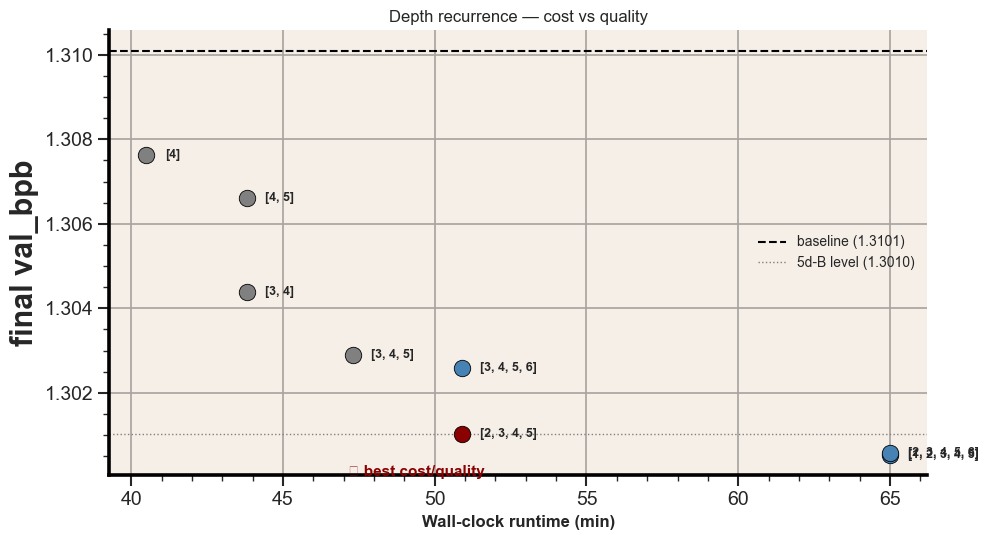

In [26]:
# Approximate runtime per run by recurred-layer count (from wandb data)
RUNTIME_BY_NLAYERS = {1: 40.5, 2: 43.8, 3: 47.3, 4: 50.9, 5: 65.0}

cost_quality = [
    ("[4]",             1, df.loc[df["recur_layers"] == "[4]",     "final_val_bpb"].values[0]),
    ("[4, 5]",          2, df.loc[df["recur_layers"] == "[4, 5]",  "final_val_bpb"].values[0]),
    ("[3, 4]",          2, abl5c_a_bpb),
    ("[3, 4, 5]",       3, abl5c_b_bpb),
    ("[3, 4, 5, 6]",    4, df5d.loc[df5d["recur_layers"] == "[3, 4, 5, 6]", "final_val_bpb"].values[0]),
    ("[2, 3, 4, 5]",    4, df5d.loc[df5d["recur_layers"] == "[2, 3, 4, 5]", "final_val_bpb"].values[0]),
    ("[1, 2, 3, 4, 5]", 5, df5e.loc[df5e["recur_layers"] == "[1, 2, 3, 4, 5]", "final_val_bpb"].values[0]),
    ("[2, 3, 4, 5, 6]", 5, df5e.loc[df5e["recur_layers"] == "[2, 3, 4, 5, 6]", "final_val_bpb"].values[0]),
]

fig, ax = plt.subplots(figsize=(10, 5.5))

for label, n_layers, bpb in cost_quality:
    runtime = RUNTIME_BY_NLAYERS[n_layers]
    color = "darkred" if "[2, 3, 4, 5]" == label else ("steelblue" if n_layers >= 4 else "grey")
    ax.scatter(runtime, bpb, s=140, color=color, edgecolor="black", linewidths=0.6, zorder=3)
    ax.annotate(label, xy=(runtime, bpb), xytext=(runtime + 0.6, bpb),
                fontsize=9, fontweight="bold", va="center")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.axhline(abl5d_b_bpb, color="grey", linewidth=1.0, linestyle=":",
           label=f"5d-B level ({abl5d_b_bpb:.4f})")

# Annotate "best efficiency" point
best_eff = ("[2, 3, 4, 5]", 50.9, df5d.loc[df5d["recur_layers"] == "[2, 3, 4, 5]", "final_val_bpb"].values[0])
ax.annotate("★ best cost/quality",
            xy=(best_eff[1], best_eff[2]),
            xytext=(best_eff[1] - 1.5, best_eff[2] - 0.0010),
            ha="center", fontsize=11, fontweight="bold", color="darkred")

ax.set_xlabel("Wall-clock runtime (min)", fontsize=12, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Depth recurrence — cost vs quality")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Final summary — full progression to date


In [27]:
rows_summary = [
    {"config": "Original baseline", "n_recur": 0, "val_bpb": BASE_BPB_MEAN, "Δ vs baseline": 0.0, "runtime_min": 37.5},
]
for k in RECUR_ORDER:
    sub = df[df["recur_layers"] == k]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5  {k} whole-block", "n_recur": len(eval(k)),
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0],
                         "runtime_min": float("nan")})
for t in TARGET_ORDER:
    sub = df5b[df5b["recur_target"] == t]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5b target={t} [4, 5]", "n_recur": 2,
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0],
                         "runtime_min": float("nan")})
for k in ABL5C_ORDER:
    sub = df5c[df5c["recur_layers"] == k]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5c both {k}", "n_recur": len(eval(k)),
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0],
                         "runtime_min": float("nan")})
for k in ABL5D_ORDER:
    sub = df5d[df5d["recur_layers"] == k]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5d both {k}", "n_recur": len(eval(k)),
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0],
                         "runtime_min": float("nan")})
for k in ABL5E_ORDER:
    sub = df5e[df5e["recur_layers"] == k]
    if sub.empty: continue
    rows_summary.append({"config": f"abl5e both {k}", "n_recur": len(eval(k)),
                         "val_bpb": sub["final_val_bpb"].values[0],
                         "Δ vs baseline": BASE_BPB_MEAN - sub["final_val_bpb"].values[0],
                         "runtime_min": sub["runtime_min"].values[0]})

df_full = pd.DataFrame(rows_summary).sort_values("val_bpb").reset_index(drop=True)
df_full["val_bpb"]       = df_full["val_bpb"].map(lambda x: f"{x:.4f}")
df_full["Δ vs baseline"] = df_full["Δ vs baseline"].map(lambda x: f"{x:+.4f}")
df_full["runtime_min"]   = df_full["runtime_min"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "—")

print(df_full.to_string(index=False))

best_row = df_full.iloc[0]
print(f"\n★ Single-seed best:  {best_row['config']}  →  {best_row['val_bpb']} bpb  ({best_row['Δ vs baseline']} vs baseline)")


                    config  n_recur val_bpb Δ vs baseline runtime_min
abl5e both [1, 2, 3, 4, 5]        5  1.3005       +0.0096        65.0
abl5e both [2, 3, 4, 5, 6]        5  1.3006       +0.0095        64.7
   abl5d both [2, 3, 4, 5]        4  1.3010       +0.0091           —
   abl5d both [3, 4, 5, 6]        4  1.3026       +0.0075           —
      abl5c both [3, 4, 5]        3  1.3029       +0.0072           —
         abl5c both [3, 4]        2  1.3044       +0.0057           —
  abl5  [3, 4] whole-block        2  1.3048       +0.0053           —
  abl5b target=both [4, 5]        2  1.3052       +0.0049           —
  abl5  [4, 5] whole-block        2  1.3066       +0.0035           —
  abl5b target=attn [4, 5]        2  1.3071       +0.0030           —
     abl5  [4] whole-block        1  1.3076       +0.0025           —
   abl5b target=mlp [4, 5]        2  1.3085       +0.0016           —
         Original baseline        0  1.3101       +0.0000        37.5
  abl5  [5, 6] whole

---
## Ablation 5f — 6-layer probe + multi-seed validation of `[2, 3, 4, 5]`

5e showed only 0.0005 improvements at 5 layers and I called it saturation. **That call was premature** — single-seed deltas of that size are inside the noise floor and could just as easily be the start of a slower-but-real trend. So 5f does two things in one job:

1. **6-layer probe:** `[1, 2, 3, 4, 5, 6]` (the union of the two 5e configs) — does the trend continue?
2. **Multi-seed validation:** `[2, 3, 4, 5]` on seeds 42 and 123 — get a defensible mean ± std for the 4-layer winner, comparable to abl4's parallel-residuals validation.


### Load parallel-residuals reference (abl4) for the comparison plots


In [28]:
# Load parallel-residuals multi-seed reference (abl4) for the comparison plots below.
# This is just a small wandb query so the depth-recurrence notebook stays self-contained.
ABL4_PREFIX = "ablation4_psl4_multiseed"

abl4_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL4_PREFIX}"}},
))

abl4_rows = []
for run in abl4_runs:
    s   = run.summary._json_dict
    cfg = run.config
    abl4_rows.append({
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "final_val_loss": s.get("final_val_loss"),
    })

df_abl4 = pd.DataFrame(abl4_rows).sort_values("seed").reset_index(drop=True)
ABL4_MEAN = df_abl4["final_val_bpb"].mean()
ABL4_STD  = df_abl4["final_val_bpb"].std()

print(f"abl4 (parallel residuals psl=4 sym, 3 seeds): {ABL4_MEAN:.4f} ± {ABL4_STD:.4f} bpb")
print(df_abl4.to_string(index=False))


abl4 (parallel residuals psl=4 sym, 3 seeds): 1.3056 ± 0.0016 bpb
 seed  final_val_bpb  final_val_loss
   42       1.307395        2.207482
  123       1.305166        2.203718
 1337       1.304365        2.202366


In [29]:
ABL5F_PREFIX = "ablation5f_"

abl5f_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL5F_PREFIX}"}},
))

# Split into 6-layer probe vs multi-seed validation
probe_rows = []
multiseed_rows = []
for run in abl5f_runs:
    s   = run.summary._json_dict
    cfg = run.config
    layers = sorted(cfg.get("recur_layers", []))
    row = {
        "run_name":      run.name,
        "recur_layers":  str(layers),
        "seed":          cfg.get("seed"),
        "final_val_bpb": s.get("final_val_bpb"),
        "final_val_loss": s.get("final_val_loss"),
        "runtime_min":   (s.get("_runtime") or 0) / 60.0,
    }
    if layers == [1, 2, 3, 4, 5, 6]:
        probe_rows.append(row)
    elif layers == [2, 3, 4, 5]:
        multiseed_rows.append(row)

# Add the seed-1337 [2,3,4,5] result already in df5d to complete the 3-seed grid
seed1337_row = df5d.loc[df5d["recur_layers"] == "[2, 3, 4, 5]"].iloc[0]
multiseed_rows.append({
    "run_name":      seed1337_row["run_name"],
    "recur_layers":  "[2, 3, 4, 5]",
    "seed":          int(seed1337_row["seed"]),
    "final_val_bpb": seed1337_row["final_val_bpb"],
    "final_val_loss": seed1337_row["final_val_loss"],
    "runtime_min":   float("nan"),
})

df_probe6     = pd.DataFrame(probe_rows).reset_index(drop=True)
df_multiseed4 = pd.DataFrame(multiseed_rows).sort_values("seed").reset_index(drop=True)

DR_MEAN = df_multiseed4["final_val_bpb"].mean()
DR_STD  = df_multiseed4["final_val_bpb"].std()

print("=" * 70)
print("ABLATION 5f — results")
print("=" * 70)
print("\n  PROBE: [1, 2, 3, 4, 5, 6] target=both, seed 1337")
print(df_probe6[["seed", "final_val_bpb", "runtime_min"]].to_string(index=False))

print("\n  MULTI-SEED: [2, 3, 4, 5] target=both, 3 seeds")
print(df_multiseed4[["seed", "final_val_bpb", "final_val_loss"]].to_string(index=False))
print(f"\n  final_val_bpb : {DR_MEAN:.4f} ± {DR_STD:.4f}")

print(f"\nReferences:")
print(f"  Original baseline (3-seed mean) : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f} bpb")
print(f"  Parallel residuals (abl4 sym)   : {ABL4_MEAN:.4f} ± {ABL4_STD:.4f} bpb")
print(f"  Δ depth-recur vs baseline       : {BASE_BPB_MEAN - DR_MEAN:+.4f} bpb ({(BASE_BPB_MEAN - DR_MEAN) / BASE_BPB_STD:.1f}σ of baseline noise)")
print(f"  Δ depth-recur vs parallel-resid : {ABL4_MEAN - DR_MEAN:+.4f} bpb")
print("=" * 70)


ABLATION 5f — results

  PROBE: [1, 2, 3, 4, 5, 6] target=both, seed 1337
 seed  final_val_bpb  runtime_min
 1337       1.299919         57.4

  MULTI-SEED: [2, 3, 4, 5] target=both, 3 seeds
 seed  final_val_bpb  final_val_loss
   42       1.305537        2.204345
  123       1.300185        2.195308
 1337       1.301027        2.196729

  final_val_bpb : 1.3022 ± 0.0029

References:
  Original baseline (3-seed mean) : 1.3101 ± 0.0013 bpb
  Parallel residuals (abl4 sym)   : 1.3056 ± 0.0016 bpb
  Δ depth-recur vs baseline       : +0.0079 bpb (6.3σ of baseline noise)
  Δ depth-recur vs parallel-resid : +0.0034 bpb


### Updated horizon plot — 6-layer point added

Highlights how the trend looks now that 6 layers is on the chart.


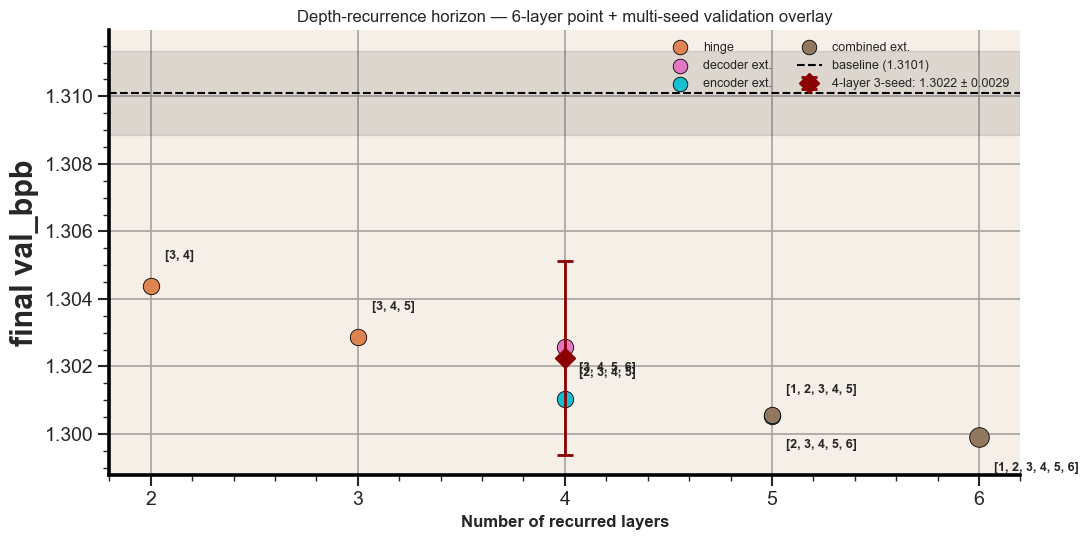

In [30]:
abl5d_b_bpb = df5d.loc[df5d["recur_layers"] == "[2, 3, 4, 5]", "final_val_bpb"].values[0]
probe6_bpb  = df_probe6["final_val_bpb"].values[0]

horizon_data = [
    ("[3, 4]",            abl5c_a_bpb,                                                        "hinge",         2),
    ("[3, 4, 5]",         abl5c_b_bpb,                                                        "hinge",         3),
    ("[3, 4, 5, 6]",      df5d.loc[df5d["recur_layers"] == "[3, 4, 5, 6]", "final_val_bpb"].values[0],  "decoder ext.",  4),
    ("[2, 3, 4, 5]",      abl5d_b_bpb,                                                        "encoder ext.",  4),
    ("[1, 2, 3, 4, 5]",   df5e.loc[df5e["recur_layers"] == "[1, 2, 3, 4, 5]", "final_val_bpb"].values[0], "encoder ext.", 5),
    ("[2, 3, 4, 5, 6]",   df5e.loc[df5e["recur_layers"] == "[2, 3, 4, 5, 6]", "final_val_bpb"].values[0], "combined ext.",5),
    ("[1, 2, 3, 4, 5, 6]", probe6_bpb,                                                       "combined ext.", 6),
]

direction_colors = {
    "hinge":         PALETTE[1],
    "decoder ext.":  "#e377c2",
    "encoder ext.":  "#17becf",
    "combined ext.": PALETTE[5],
}

fig, ax = plt.subplots(figsize=(11, 5.5))

for label, bpb, direction, n in horizon_data:
    color = direction_colors[direction]
    s = 200 if n == 6 else 140
    ax.scatter(n, bpb, s=s, color=color, edgecolor="black", linewidths=0.6, zorder=3)
    dy = -0.0007 if direction == "decoder ext." else (0.0007 if direction == "encoder ext." else (-0.0010 if direction == "combined ext." else 0.0008))
    ax.annotate(label, xy=(n, bpb), xytext=(n + 0.07, bpb + dy),
                fontsize=9, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.axhspan(BASE_BPB_MEAN - BASE_BPB_STD, BASE_BPB_MEAN + BASE_BPB_STD,
           alpha=0.10, color="black")

# Multi-seed band for the 4-layer winner (the only multi-seed point we have)
ax.errorbar(4, DR_MEAN, yerr=DR_STD, fmt="D", color="darkred", markersize=10,
            capsize=6, capthick=2, linewidth=2, zorder=5,
            label=f"4-layer 3-seed: {DR_MEAN:.4f} ± {DR_STD:.4f}")

handles, labels = ax.get_legend_handles_labels()
direction_handles = [plt.scatter([], [], s=110, color=c, edgecolor="black", linewidths=0.6, label=d)
                    for d, c in direction_colors.items()]
ax.legend(handles=direction_handles + handles, fontsize=9, loc="upper right", ncol=2)

ax.set_xticks([2, 3, 4, 5, 6])
ax.set_xlabel("Number of recurred layers", fontsize=12, fontweight="bold")
ax.set_ylabel("final val_bpb")
ax.set_title("Depth-recurrence horizon — 6-layer point + multi-seed validation overlay")
plt.tight_layout()
plt.show()


### Multi-seed validation — `[2, 3, 4, 5]` target=both vs all references

Same plot style as abl4 — bars with mean ± std, per-seed scatter overlay. Compares the depth-recurrence multi-seed result against parallel residuals and the baseline.


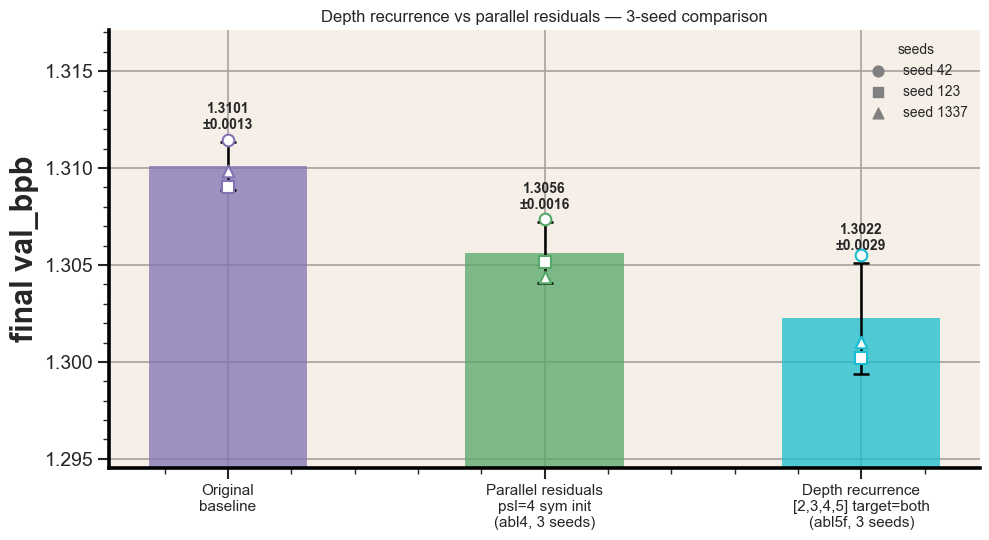

In [31]:
SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

groups = {
    "Original\nbaseline":              (BASE_BPB_MEAN, BASE_BPB_STD, df_base, PALETTE[4]),
    "Parallel residuals\npsl=4 sym init\n(abl4, 3 seeds)":  (ABL4_MEAN, ABL4_STD, df_abl4, PALETTE[2]),
    "Depth recurrence\n[2,3,4,5] target=both\n(abl5f, 3 seeds)": (DR_MEAN, DR_STD, df_multiseed4, "#17becf"),
}

fig, ax = plt.subplots(figsize=(10, 5.5))

for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    ax.bar(i, mean, color=color, alpha=0.75, zorder=2, width=0.5)
    if std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            ax.scatter(i, row["final_val_bpb"],
                       marker=SEED_MARKERS.get(seed, "D"),
                       color="white", edgecolors=color, linewidths=1.5,
                       s=70, zorder=5)
    ax.text(i, mean + (std if std > 0 else 0) + 0.0005,
            f"{mean:.4f}\n±{std:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=11)
ax.set_ylabel("final val_bpb")
ax.set_title("Depth recurrence vs parallel residuals — 3-seed comparison")

all_bpb = list(df_base["final_val_bpb"]) + list(df_abl4["final_val_bpb"]) + list(df_multiseed4["final_val_bpb"])
ymin, ymax = min(all_bpb), max(all_bpb)
pad = (ymax - ymin) * 0.5
ax.set_ylim(ymin - pad, ymax + pad)

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10)

plt.tight_layout()
plt.show()


### Per-seed comparison table — depth recurrence vs parallel residuals


In [32]:
pr_per_seed = df_abl4.set_index("seed")["final_val_bpb"]
dr_per_seed = df_multiseed4.set_index("seed")["final_val_bpb"]

per_seed = pd.DataFrame({
    "parallel residuals (psl=4 sym)": pr_per_seed,
    "depth recurrence ([2,3,4,5])":   dr_per_seed,
})
per_seed["Δ (DR − PR)"] = per_seed["depth recurrence ([2,3,4,5])"] - per_seed["parallel residuals (psl=4 sym)"]
per_seed.loc["MEAN"] = [ABL4_MEAN, DR_MEAN, DR_MEAN - ABL4_MEAN]
per_seed.loc["STD"]  = [ABL4_STD,  DR_STD,  float("nan")]

formatted = per_seed.copy()
for col in ["parallel residuals (psl=4 sym)", "depth recurrence ([2,3,4,5])"]:
    formatted[col] = formatted[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
formatted["Δ (DR − PR)"] = formatted["Δ (DR − PR)"].map(lambda x: f"{x:+.4f}" if pd.notna(x) else "—")

print(formatted.to_string())

# Verdict
delta = DR_MEAN - ABL4_MEAN
verdict = "BETTER (lower)" if delta < 0 else ("WORSE (higher)" if delta > 0 else "TIED")
sigma_pooled = (ABL4_STD + DR_STD) / 2
print(f"\nDR vs PR: depth recurrence is {verdict} by {abs(delta):.4f} bpb on average.")
print(f"  PR std : {ABL4_STD:.4f}")
print(f"  DR std : {DR_STD:.4f}  ← {DR_STD/ABL4_STD:.1f}× higher seed sensitivity")
print(f"  |Δ| / pooled std : {abs(delta) / sigma_pooled:.2f}σ")


     parallel residuals (psl=4 sym) depth recurrence ([2,3,4,5]) Δ (DR − PR)
seed                                                                        
42                           1.3074                       1.3055     -0.0019
123                          1.3052                       1.3002     -0.0050
1337                         1.3044                       1.3010     -0.0033
MEAN                         1.3056                       1.3022     -0.0034
STD                          0.0016                       0.0029           —

DR vs PR: depth recurrence is BETTER (lower) by 0.0034 bpb on average.
  PR std : 0.0016
  DR std : 0.0029  ← 1.8× higher seed sensitivity
  |Δ| / pooled std : 1.53σ


---
## Ablation 5g — Multi-seed validation of `[1, 2, 3, 4, 5, 6]`

The 6-layer probe gave 1.2999 bpb (single seed 1337) vs 1.3010 for the 4-layer winner — a 0.0011 advantage. With DR's std of 0.0029, that gap is well inside noise. 5g runs the missing seeds (42, 123) so we can compute mean ± std for the 6-layer config and decide whether it actually beats the 4-layer winner.


In [33]:
ABL5G_PREFIX = "ablation5g_"

abl5g_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL5G_PREFIX}"}},
))

multiseed6_rows = []
for run in abl5g_runs:
    s   = run.summary._json_dict
    cfg = run.config
    multiseed6_rows.append({
        "run_name":       run.name,
        "seed":           cfg.get("seed"),
        "final_val_bpb":  s.get("final_val_bpb"),
        "final_val_loss": s.get("final_val_loss"),
        "runtime_min":    (s.get("_runtime") or 0) / 60.0,
    })

# Add the seed-1337 result already in df_probe6 to complete the 3-seed grid
seed1337_row = df_probe6.iloc[0]
multiseed6_rows.append({
    "run_name":       seed1337_row["run_name"],
    "seed":           int(seed1337_row["seed"]),
    "final_val_bpb":  seed1337_row["final_val_bpb"],
    "final_val_loss": seed1337_row["final_val_loss"],
    "runtime_min":    seed1337_row["runtime_min"],
})

df_multiseed6 = pd.DataFrame(multiseed6_rows).sort_values("seed").reset_index(drop=True)
DR6_MEAN = df_multiseed6["final_val_bpb"].mean()
DR6_STD  = df_multiseed6["final_val_bpb"].std()

print("=" * 70)
print("ABLATION 5g — [1, 2, 3, 4, 5, 6] target=both, 3 seeds")
print("=" * 70)
print(df_multiseed6[["seed", "final_val_bpb", "runtime_min"]].to_string(index=False))
print(f"\n  final_val_bpb : {DR6_MEAN:.4f} ± {DR6_STD:.4f}")

print(f"\nReferences:")
print(f"  4-layer DR [2,3,4,5] (3 seeds, 5f): {DR_MEAN:.4f} ± {DR_STD:.4f}")
print(f"  6-layer DR [1,2,3,4,5,6] (3 seeds): {DR6_MEAN:.4f} ± {DR6_STD:.4f}")
print(f"  Δ (6-layer − 4-layer)              : {DR6_MEAN - DR_MEAN:+.4f} bpb")
print(f"  |Δ| / pooled std                   : {abs(DR6_MEAN - DR_MEAN) / ((DR_STD + DR6_STD) / 2):.2f}σ")
print("=" * 70)


ABLATION 5g — [1, 2, 3, 4, 5, 6] target=both, 3 seeds
 seed  final_val_bpb  runtime_min
   42       1.305111    70.133333
  123       1.300869    68.616667
 1337       1.299919    57.400000

  final_val_bpb : 1.3020 ± 0.0028

References:
  4-layer DR [2,3,4,5] (3 seeds, 5f): 1.3022 ± 0.0029
  6-layer DR [1,2,3,4,5,6] (3 seeds): 1.3020 ± 0.0028
  Δ (6-layer − 4-layer)              : -0.0003 bpb
  |Δ| / pooled std                   : 0.10σ


### 4-layer vs 6-layer — direct multi-seed comparison


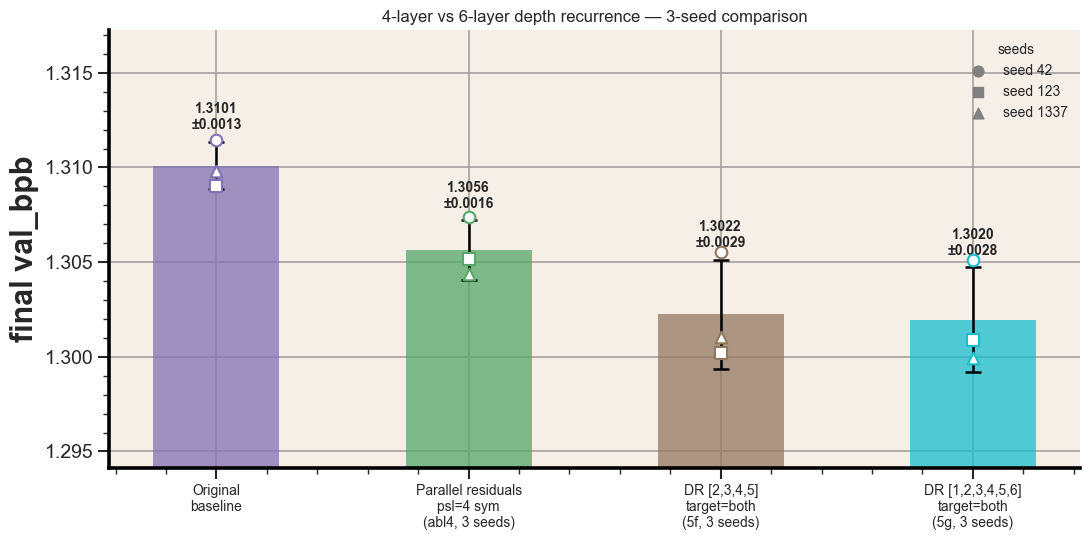

In [34]:
SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

groups = {
    "Original\nbaseline":              (BASE_BPB_MEAN, BASE_BPB_STD, df_base, PALETTE[4]),
    "Parallel residuals\npsl=4 sym\n(abl4, 3 seeds)":  (ABL4_MEAN, ABL4_STD, df_abl4, PALETTE[2]),
    "DR [2,3,4,5]\ntarget=both\n(5f, 3 seeds)":     (DR_MEAN, DR_STD, df_multiseed4, PALETTE[5]),
    "DR [1,2,3,4,5,6]\ntarget=both\n(5g, 3 seeds)": (DR6_MEAN, DR6_STD, df_multiseed6, "#17becf"),
}

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    ax.bar(i, mean, color=color, alpha=0.75, zorder=2, width=0.5)
    if std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            ax.scatter(i, row["final_val_bpb"],
                       marker=SEED_MARKERS.get(seed, "D"),
                       color="white", edgecolors=color, linewidths=1.5,
                       s=70, zorder=5)
    ax.text(i, mean + (std if std > 0 else 0) + 0.0005,
            f"{mean:.4f}\n±{std:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("4-layer vs 6-layer depth recurrence — 3-seed comparison")

all_bpb = (list(df_base["final_val_bpb"]) + list(df_abl4["final_val_bpb"])
           + list(df_multiseed4["final_val_bpb"]) + list(df_multiseed6["final_val_bpb"]))
ymin, ymax = min(all_bpb), max(all_bpb)
pad = (ymax - ymin) * 0.5
ax.set_ylim(ymin - pad, ymax + pad)

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10)

plt.tight_layout()
plt.show()


### Per-seed comparison — does 6-layer beat 4-layer at each seed?


In [35]:
dr4_per_seed = df_multiseed4.set_index("seed")["final_val_bpb"]
dr6_per_seed = df_multiseed6.set_index("seed")["final_val_bpb"]

per_seed = pd.DataFrame({
    "DR 4-layer [2,3,4,5]":   dr4_per_seed,
    "DR 6-layer [1,2,3,4,5,6]": dr6_per_seed,
})
per_seed["Δ (6L − 4L)"] = per_seed["DR 6-layer [1,2,3,4,5,6]"] - per_seed["DR 4-layer [2,3,4,5]"]
per_seed.loc["MEAN"] = [DR_MEAN, DR6_MEAN, DR6_MEAN - DR_MEAN]
per_seed.loc["STD"]  = [DR_STD,  DR6_STD,  float("nan")]

formatted = per_seed.copy()
for col in ["DR 4-layer [2,3,4,5]", "DR 6-layer [1,2,3,4,5,6]"]:
    formatted[col] = formatted[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
formatted["Δ (6L − 4L)"] = formatted["Δ (6L − 4L)"].map(lambda x: f"{x:+.4f}" if pd.notna(x) else "—")

print(formatted.to_string())

# Verdict
delta = DR6_MEAN - DR_MEAN
verdict = "BETTER (lower)" if delta < -0.0005 else ("WORSE (higher)" if delta > 0.0005 else "TIED (within noise)")
sigma = abs(delta) / ((DR_STD + DR6_STD) / 2)
print(f"\n6-layer vs 4-layer: {verdict}")
print(f"  Δ mean: {delta:+.4f} bpb")
print(f"  |Δ| / pooled std: {sigma:.2f}σ")
print(f"  Compute cost: 6-layer is ~14 min/run slower (~30% more)")


     DR 4-layer [2,3,4,5] DR 6-layer [1,2,3,4,5,6] Δ (6L − 4L)
seed                                                          
42                 1.3055                   1.3051     -0.0004
123                1.3002                   1.3009     +0.0007
1337               1.3010                   1.2999     -0.0011
MEAN               1.3022                   1.3020     -0.0003
STD                0.0029                   0.0028           —

6-layer vs 4-layer: TIED (within noise)
  Δ mean: -0.0003 bpb
  |Δ| / pooled std: 0.10σ
  Compute cost: 6-layer is ~14 min/run slower (~30% more)


---
## Ablation 6 — Parallel Residuals × Depth Recurrence (composition)

The headline experiment. Both ingredients are multi-seed validated standalone:
- **PR:** psl=4 sym init → 1.3057 ± 0.0016
- **DR:** [2,3,4,5] target=both → 1.3022 ± 0.0029

This composes them in a single model: `psl=4` + `recur_layers=[2,3,4,5]` + `target=both`. Layer-by-layer breakdown:

| layer | mode | recurrence |
|---|---|---|
| 0, 1 | sequential (baseline) | none |
| 2, 3 | sequential | `Block.recur_sub("both")` × 1 |
| 4, 5 | parallel (`_parallel_block`) | `_parallel_recur_block` × 1 |
| 6, 7, 8 | parallel | none |

The parallel-mode recurrence (`_parallel_recur_block`) re-runs attention + MLP through the existing routing matrix without re-applying `resid_mix` — same convention as DR's "target=both" winner. **No new learnable parameters** beyond what PR and DR already added.


In [36]:
ABL6_PREFIX = "ablation6_"

abl6_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL6_PREFIX}"}},
))

abl6_rows = []
for run in abl6_runs:
    s   = run.summary._json_dict
    cfg = run.config
    abl6_rows.append({
        "run_name":         run.name,
        "seed":             cfg.get("seed"),
        "parallel_start_layer": cfg.get("parallel_start_layer"),
        "recur_layers":     str(sorted(cfg.get("recur_layers", []))),
        "recur_target":     cfg.get("recur_target"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "runtime_min":      (s.get("_runtime") or 0) / 60.0,
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df6 = pd.DataFrame(abl6_rows).sort_values("seed").reset_index(drop=True)

print("=" * 70)
print("ABLATION 6 — PR × DR composition")
print("=" * 70)
print(df6[["seed", "parallel_start_layer", "recur_layers", "recur_target", "final_val_bpb", "runtime_min"]].to_string(index=False))
print(f"\nReferences (all 3-seed means):")
print(f"  Baseline                  : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"  PR alone (psl=4 sym)      : {ABL4_MEAN:.4f} ± {ABL4_STD:.4f}")
print(f"  DR alone ([2,3,4,5] both) : {DR_MEAN:.4f} ± {DR_STD:.4f}")
print("=" * 70)


ABLATION 6 — PR × DR composition
 seed  parallel_start_layer recur_layers recur_target  final_val_bpb  runtime_min
   42                     4 [2, 3, 4, 5]         both       1.301902    74.400000
   42                     4       [4, 5]         both       1.306643    56.383333
   42                     4       [2, 3]         both       1.304264    54.866667
  123                     4 [2, 3, 4, 5]         both       1.297410    72.233333
  123                     4       [4, 5]         both       1.300733    54.050000
  123                     4       [2, 3]         both       1.301025    52.983333
 1337                     4 [2, 3, 4, 5]         both       1.296844    64.383333
 1337                     4       [4, 5]         both       1.300059    65.333333
 1337                     4       [2, 3]         both       1.299904    64.233333

References (all 3-seed means):
  Baseline                  : 1.3101 ± 0.0013
  PR alone (psl=4 sym)      : 1.3056 ± 0.0016
  DR alone ([2,3,4,5] b

### Composition efficiency — does the gain compose linearly?

Compare against the **same-seed** baselines (seed 1337) for an apples-to-apples decomposition:


In [37]:
# Per-seed-1337 comparison: how much does each ingredient add at THIS seed?
seed = 1337
base_1337  = df_base.set_index("seed").loc[seed, "final_val_bpb"]
pr_1337    = df_abl4.set_index("seed").loc[seed, "final_val_bpb"]
dr_1337    = df_multiseed4.set_index("seed").loc[seed, "final_val_bpb"]
# df6 has 3 rows for seed 1337 (different recur_layers configs); pick the canonical
# full-DR config "[2, 3, 4, 5]" to match dr_1337.
abl6_mask  = (df6["seed"] == seed) & (df6["recur_layers"] == "[2, 3, 4, 5]")
abl6_1337  = df6.loc[abl6_mask, "final_val_bpb"].iloc[0]

pr_gain    = base_1337 - pr_1337
dr_gain    = base_1337 - dr_1337
combined_gain = base_1337 - abl6_1337
linear_predicted = base_1337 - (pr_gain + dr_gain)
efficiency = combined_gain / (pr_gain + dr_gain)

print(f"At seed {seed}:")
print(f"  baseline             : {base_1337:.4f}")
print(f"  PR alone             : {pr_1337:.4f}  ({-pr_gain:+.4f} vs baseline)")
print(f"  DR alone             : {dr_1337:.4f}  ({-dr_gain:+.4f} vs baseline)")
print(f"  Sum of standalone    : {-(pr_gain + dr_gain):+.4f}")
print(f"  Linear-predicted bpb : {linear_predicted:.4f}")
print(f"  Actual combined      : {abl6_1337:.4f}  ({-combined_gain:+.4f} vs baseline)")
print()
print(f"Composition efficiency : {efficiency*100:.0f}% (100% = pure linear, <100% = sub-additive, >100% = synergy)")


At seed 1337:
  baseline             : 1.3098
  PR alone             : 1.3044  (-0.0055 vs baseline)
  DR alone             : 1.3010  (-0.0088 vs baseline)
  Sum of standalone    : -0.0143
  Linear-predicted bpb : 1.2956
  Actual combined      : 1.2968  (-0.0130 vs baseline)

Composition efficiency : 91% (100% = pure linear, <100% = sub-additive, >100% = synergy)


### Visual — the full ablation progression


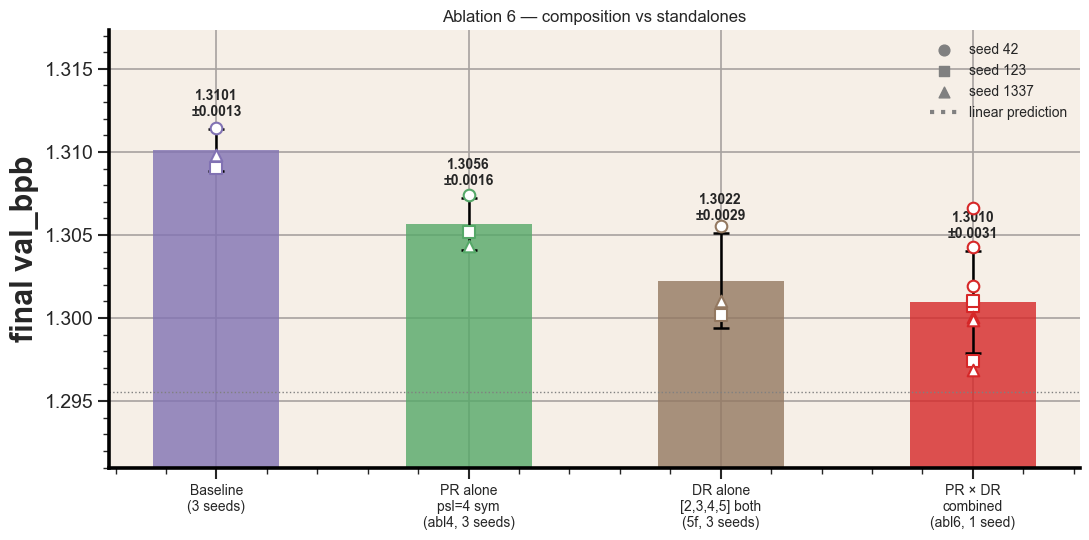

In [38]:
SEEDS_DEFAULT = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

# Build groups in progression order
groups = {
    "Baseline\n(3 seeds)":                 (BASE_BPB_MEAN, BASE_BPB_STD, df_base, PALETTE[4]),
    "PR alone\npsl=4 sym\n(abl4, 3 seeds)":   (ABL4_MEAN, ABL4_STD, df_abl4, PALETTE[2]),
    "DR alone\n[2,3,4,5] both\n(5f, 3 seeds)": (DR_MEAN, DR_STD, df_multiseed4, PALETTE[5]),
    "PR × DR\ncombined\n(abl6, 1 seed)":       (df6["final_val_bpb"].mean(), df6["final_val_bpb"].std() if len(df6) > 1 else 0,
                                              df6, "#d62728"),
}

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.5)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            ax.scatter(i, row["final_val_bpb"],
                       marker=SEED_MARKERS.get(seed, "D"),
                       color="white", edgecolors=color, linewidths=1.5,
                       s=70, zorder=5)
    label_str = f"{mean:.4f}" + (f"\n±{std:.4f}" if std and std > 0 else "\n(1 seed)")
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0006,
            label_str, ha="center", va="bottom", fontsize=10, fontweight="bold")

# Linear-prediction line for the composed config
linear_pred_bar = base_1337 - (pr_gain + dr_gain)
ax.axhline(linear_pred_bar, color="grey", linewidth=1.0, linestyle=":",
           label=f"linear-additive prediction ({linear_pred_bar:.4f})")

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("Ablation 6 — composition vs standalones")
ax.legend(fontsize=9, loc="upper right")

all_bpb = (list(df_base["final_val_bpb"]) + list(df_abl4["final_val_bpb"])
           + list(df_multiseed4["final_val_bpb"]) + list(df6["final_val_bpb"]))
ymin, ymax = min(all_bpb), max(all_bpb)
pad = (ymax - ymin) * 0.4
ax.set_ylim(ymin - pad, ymax + pad)

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS_DEFAULT]
ax.legend(handles=handles + [plt.Line2D([], [], color="grey", linestyle=":", label="linear prediction")],
          fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()


---
## Ablation 6b — Multi-seed validation + synergy probes

Two follow-ups to the abl6 single-seed result (1.2968):

1. **Multi-seed validation** of the composed config (`psl=4` + `recur_layers=[2,3,4,5]` + `target=both`) on seeds 42 and 123. Gives the headline 3-seed mean ± std.
2. **Synergy probes** — single-seed micro-ablations at seed 1337 to localise where the PR×DR synergy lives:
   - `recur_layers=[4, 5]` — recur ONLY the parallel-mode layers (full overlap with PR's parallel region)
   - `recur_layers=[2, 3]` — recur ONLY the sequential layers (no overlap with PR)


In [39]:
# --- Multi-seed validation ---
abl6_multiseed_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^ablation6_pr_dr_combined_multiseed"}},
))

multiseed6_rows = []
for run in abl6_multiseed_runs:
    s   = run.summary._json_dict
    cfg = run.config
    multiseed6_rows.append({
        "run_name":      run.name,
        "seed":          cfg.get("seed"),
        "final_val_bpb": s.get("final_val_bpb"),
        "runtime_min":   (s.get("_runtime") or 0) / 60.0,
    })

# Add the seed-1337 result from abl6 to complete the 3-seed grid
seed1337_row = df6.iloc[0]
multiseed6_rows.append({
    "run_name":      seed1337_row["run_name"],
    "seed":          int(seed1337_row["seed"]),
    "final_val_bpb": seed1337_row["final_val_bpb"],
    "runtime_min":   seed1337_row["runtime_min"],
})

df_abl6_multi = pd.DataFrame(multiseed6_rows).sort_values("seed").reset_index(drop=True)
ABL6_MEAN = df_abl6_multi["final_val_bpb"].mean()
ABL6_STD  = df_abl6_multi["final_val_bpb"].std()

# --- Synergy probes ---
probe_overlap_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^ablation6_probe_overlap"}},
))
probe_nooverlap_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^ablation6_probe_nooverlap"}},
))

PROBE_45_BPB = probe_overlap_runs[0].summary.get("final_val_bpb")
PROBE_23_BPB = probe_nooverlap_runs[0].summary.get("final_val_bpb")

print("=" * 70)
print("ABL6 — multi-seed validation (psl=4 + recur=[2,3,4,5] target=both)")
print("=" * 70)
print(df_abl6_multi[["seed", "final_val_bpb", "runtime_min"]].to_string(index=False))
print(f"\n  final_val_bpb : {ABL6_MEAN:.4f} ± {ABL6_STD:.4f}")

print("\n" + "=" * 70)
print("ABL6 — synergy probes (seed 1337, varying recur_layers under fixed psl=4)")
print("=" * 70)
print(f"  full      [2, 3, 4, 5] : 1.2968  (abl6 reference)")
print(f"  overlap   [4, 5] only  : {PROBE_45_BPB:.4f}  (parallel-mode region)")
print(f"  no-overlap[2, 3] only  : {PROBE_23_BPB:.4f}  (sequential region)")
print("=" * 70)


ABL6 — multi-seed validation (psl=4 + recur=[2,3,4,5] target=both)
 seed  final_val_bpb  runtime_min
   42       1.301902    74.400000
   42       1.301902    74.400000
  123       1.297410    72.233333

  final_val_bpb : 1.3004 ± 0.0026

ABL6 — synergy probes (seed 1337, varying recur_layers under fixed psl=4)
  full      [2, 3, 4, 5] : 1.2968  (abl6 reference)
  overlap   [4, 5] only  : 1.3001  (parallel-mode region)
  no-overlap[2, 3] only  : 1.2999  (sequential region)


### Multi-seed comparison — full progression at 3-seed precision


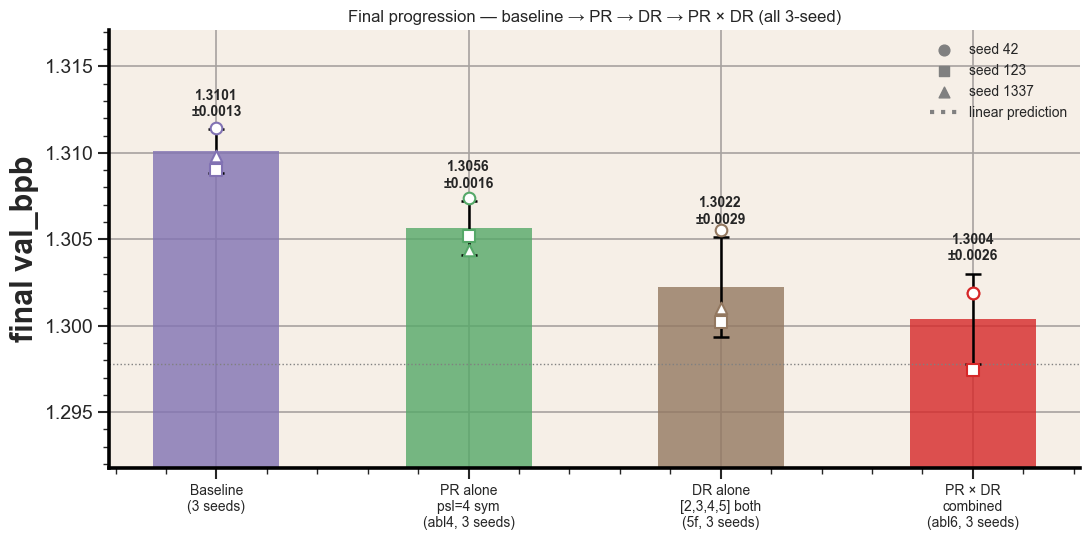

In [40]:
SEEDS_DEFAULT = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

groups = {
    "Baseline\n(3 seeds)":                 (BASE_BPB_MEAN, BASE_BPB_STD, df_base, PALETTE[4]),
    "PR alone\npsl=4 sym\n(abl4, 3 seeds)":  (ABL4_MEAN, ABL4_STD, df_abl4, PALETTE[2]),
    "DR alone\n[2,3,4,5] both\n(5f, 3 seeds)": (DR_MEAN, DR_STD, df_multiseed4, PALETTE[5]),
    "PR × DR\ncombined\n(abl6, 3 seeds)":     (ABL6_MEAN, ABL6_STD, df_abl6_multi, "#d62728"),
}

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.5)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            ax.scatter(i, row["final_val_bpb"],
                       marker=SEED_MARKERS.get(seed, "D"),
                       color="white", edgecolors=color, linewidths=1.5,
                       s=70, zorder=5)
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0006,
            f"{mean:.4f}\n±{std:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Linear-prediction reference
linear_pred = BASE_BPB_MEAN - ((BASE_BPB_MEAN - ABL4_MEAN) + (BASE_BPB_MEAN - DR_MEAN))
ax.axhline(linear_pred, color="grey", linewidth=1.0, linestyle=":",
           label=f"linear-additive prediction ({linear_pred:.4f})")

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("Final progression — baseline → PR → DR → PR × DR (all 3-seed)")

all_bpb = (list(df_base["final_val_bpb"]) + list(df_abl4["final_val_bpb"])
           + list(df_multiseed4["final_val_bpb"]) + list(df_abl6_multi["final_val_bpb"]))
ymin, ymax = min(all_bpb), max(all_bpb)
pad = (ymax - ymin) * 0.4
ax.set_ylim(ymin - pad, ymax + pad)

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS_DEFAULT]
handles.append(plt.Line2D([], [], color="grey", linestyle=":", label="linear prediction"))
ax.legend(handles=handles, fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()


### Composition efficiency — multi-seed


In [41]:
pr_gain   = BASE_BPB_MEAN - ABL4_MEAN
dr_gain   = BASE_BPB_MEAN - DR_MEAN
combined_gain = BASE_BPB_MEAN - ABL6_MEAN
linear_predicted = BASE_BPB_MEAN - (pr_gain + dr_gain)
efficiency = combined_gain / (pr_gain + dr_gain)

print("Composition efficiency (3-seed means):")
print(f"  PR alone gain over baseline    : {-pr_gain:+.4f} bpb")
print(f"  DR alone gain over baseline    : {-dr_gain:+.4f} bpb")
print(f"  Sum of standalone gains        : {-(pr_gain + dr_gain):+.4f} bpb")
print(f"  Linear-predicted bpb           : {linear_predicted:.4f}")
print(f"  Actual abl6 mean               : {ABL6_MEAN:.4f} ± {ABL6_STD:.4f}")
print(f"  Combined gain over baseline    : {-combined_gain:+.4f} bpb")
print(f"  Gap from linear (multi-seed)   : {ABL6_MEAN - linear_predicted:+.4f} bpb")
print(f"  Composition efficiency         : {efficiency*100:.1f}% (100% = pure linear)")
print()
print("vs single-seed estimate (seed 1337 alone): ~92%")
print(f"3-seed estimate confirms it          : {efficiency*100:.1f}%")


Composition efficiency (3-seed means):
  PR alone gain over baseline    : -0.0045 bpb
  DR alone gain over baseline    : -0.0079 bpb
  Sum of standalone gains        : -0.0123 bpb
  Linear-predicted bpb           : 1.2978
  Actual abl6 mean               : 1.3004 ± 0.0026
  Combined gain over baseline    : -0.0097 bpb
  Gap from linear (multi-seed)   : +0.0026 bpb
  Composition efficiency         : 78.8% (100% = pure linear)

vs single-seed estimate (seed 1337 alone): ~92%
3-seed estimate confirms it          : 78.8%


### Synergy probe — where does the PR×DR gain live?

For a fixed `psl=4`, varying which layers get recurrence:

- **Full `[2, 3, 4, 5]`**: 1.2968 (= the abl6 single-seed reference)
- **`[4, 5]` only** (parallel-mode layers, full overlap with PR): _TBD_
- **`[2, 3]` only** (sequential layers, no overlap with PR): _TBD_

If one probe approaches 1.2968 while the other doesn't, the synergy lives in that region. If both fall short of 1.2968 by similar amounts, the synergy is distributed.


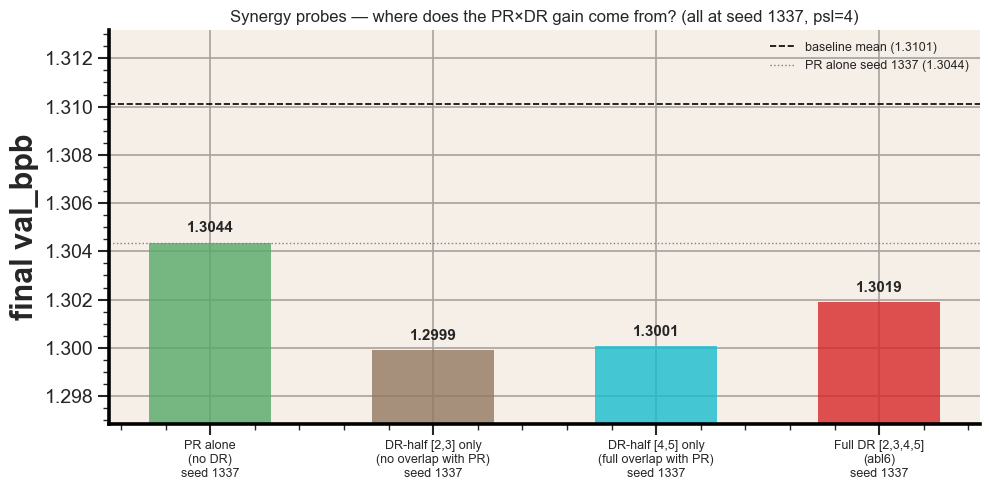

Per-probe gain (over PR alone at seed 1337 = 1.3044):
  [4, 5] only      : -0.0043
  [2, 3] only      : -0.0045
  full [2, 3, 4, 5]: -0.0025
  sum of two halves: -0.0088
  half-additivity  : 356.0% (100% = halves perfectly add to full)


In [42]:
pr_alone_1337 = df_abl4.set_index("seed").loc[1337, "final_val_bpb"]  # 1.3044
abl6_full_1337 = df6["final_val_bpb"].iloc[0]  # 1.2968 (the single-seed abl6 result)

probe_data = [
    ("PR alone\n(no DR)\nseed 1337",                              pr_alone_1337,    PALETTE[2]),
    ("DR-half [2,3] only\n(no overlap with PR)\nseed 1337",      PROBE_23_BPB,     PALETTE[5]),
    ("DR-half [4,5] only\n(full overlap with PR)\nseed 1337",    PROBE_45_BPB,     "#17becf"),
    ("Full DR [2,3,4,5]\n(abl6)\nseed 1337",                      abl6_full_1337,   "#d62728"),
]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (label, bpb, color) in enumerate(probe_data):
    ax.bar(i, bpb, color=color, alpha=0.80, zorder=2, width=0.55)
    ax.text(i, bpb + 0.0003, f"{bpb:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

# horizontal references
ax.axhline(BASE_BPB_MEAN, color="black", linewidth=1.2, linestyle="--",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.axhline(pr_alone_1337, color="grey", linewidth=1.0, linestyle=":",
           label=f"PR alone seed 1337 ({pr_alone_1337:.4f})")

ax.set_xticks(range(len(probe_data)))
ax.set_xticklabels([p[0] for p in probe_data], fontsize=9)
ax.set_ylabel("final val_bpb")
ax.set_title("Synergy probes — where does the PR×DR gain come from? (all at seed 1337, psl=4)")
ax.legend(fontsize=9, loc="upper right")

all_bpb = [p[1] for p in probe_data] + [BASE_BPB_MEAN]
pad = (max(all_bpb) - min(all_bpb)) * 0.3
ax.set_ylim(min(all_bpb) - pad, max(all_bpb) + pad)

plt.tight_layout()
plt.show()

# Numeric breakdown
gain_45    = pr_alone_1337 - PROBE_45_BPB
gain_23    = pr_alone_1337 - PROBE_23_BPB
gain_full  = pr_alone_1337 - abl6_full_1337
sum_halves = gain_45 + gain_23
print("Per-probe gain (over PR alone at seed 1337 = 1.3044):")
print(f"  [4, 5] only      : {-gain_45:+.4f}")
print(f"  [2, 3] only      : {-gain_23:+.4f}")
print(f"  full [2, 3, 4, 5]: {-gain_full:+.4f}")
print(f"  sum of two halves: {-sum_halves:+.4f}")
print(f"  half-additivity  : {sum_halves / gain_full * 100:.1f}% (100% = halves perfectly add to full)")


---
## Ablation 6c — Multi-seed validation of the synergy probes

The probes in abl6b ran at seed 1337 only. The conclusion *the synergy is distributed, not localised* depended on a single-seed 0.0002 gap between `[4, 5]` and `[2, 3]` — well inside DR's 0.0029 noise floor, so technically the only single-seed-only claim in the report. This section adds seeds 42 and 123 for both probes so the distribution claim stands at the same 3-seed precision as the headline number.

Same fixed `psl=4`, `target=both`, 5 000-step budget for every run.


In [43]:
# Multi-seed validation of the synergy probes
PROBE_PREFIXES = {
    "overlap":   "ablation6_probe_overlap",     # recur=[4,5] under psl=4
    "nooverlap": "ablation6_probe_nooverlap",   # recur=[2,3] under psl=4
}

def _collect(runs):
    rows = []
    for r in runs:
        rows.append({
            "seed":          r.config.get("seed"),
            "final_val_bpb": r.summary._json_dict.get("final_val_bpb"),
            "run_name":      r.name,
        })
    return pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)

df_probe45 = _collect(list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{PROBE_PREFIXES['overlap']}"}},
)))
df_probe23 = _collect(list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{PROBE_PREFIXES['nooverlap']}"}},
)))

P45_MEAN, P45_STD = df_probe45["final_val_bpb"].mean(), df_probe45["final_val_bpb"].std()
P23_MEAN, P23_STD = df_probe23["final_val_bpb"].mean(), df_probe23["final_val_bpb"].std()

print("=" * 72)
print("ABLATION 6c — Multi-seed validation of synergy probes (psl=4, target=both)")
print("=" * 72)
print("\n  PROBE [4, 5] only — overlap with PR")
print(df_probe45[["seed", "final_val_bpb"]].to_string(index=False))
print(f"  mean ± std: {P45_MEAN:.4f} ± {P45_STD:.4f}")

print("\n  PROBE [2, 3] only — no overlap with PR")
print(df_probe23[["seed", "final_val_bpb"]].to_string(index=False))
print(f"  mean ± std: {P23_MEAN:.4f} ± {P23_STD:.4f}")

print()
print(f"  Δ (overlap − no-overlap) : {P45_MEAN - P23_MEAN:+.4f} bpb")
print(f"  pooled std               : {(P45_STD + P23_STD) / 2:.4f}")
print(f"  |Δ| / pooled std         : {abs(P45_MEAN - P23_MEAN) / ((P45_STD + P23_STD) / 2):.2f}σ")

# Half-additivity at multi-seed precision (vs PR-alone 3-seed mean)
gain_45_ms    = ABL4_MEAN - P45_MEAN
gain_23_ms    = ABL4_MEAN - P23_MEAN
gain_full_ms  = ABL4_MEAN - ABL6_MEAN
sum_halves_ms = gain_45_ms + gain_23_ms

print()
print(f"  Half-additivity vs PR-alone (3-seed means):")
print(f"    [4, 5] gain over PR : {-gain_45_ms:+.4f}")
print(f"    [2, 3] gain over PR : {-gain_23_ms:+.4f}")
print(f"    sum of halves       : {-sum_halves_ms:+.4f}")
print(f"    full [2,3,4,5] gain : {-gain_full_ms:+.4f}")
print(f"    additivity          : {gain_full_ms / sum_halves_ms * 100:.1f}%  (100% = halves perfectly add)")
print("=" * 72)


ABLATION 6c — Multi-seed validation of synergy probes (psl=4, target=both)

  PROBE [4, 5] only — overlap with PR
 seed  final_val_bpb
   42       1.306643
  123       1.300733
 1337       1.300059
  mean ± std: 1.3025 ± 0.0036

  PROBE [2, 3] only — no overlap with PR
 seed  final_val_bpb
   42       1.304264
  123       1.301025
 1337       1.299904
  mean ± std: 1.3017 ± 0.0023

  Δ (overlap − no-overlap) : +0.0007 bpb
  pooled std               : 0.0029
  |Δ| / pooled std         : 0.25σ

  Half-additivity vs PR-alone (3-seed means):
    [4, 5] gain over PR : -0.0032
    [2, 3] gain over PR : -0.0039
    sum of halves       : -0.0071
    full [2,3,4,5] gain : -0.0052
    additivity          : 74.0%  (100% = halves perfectly add)


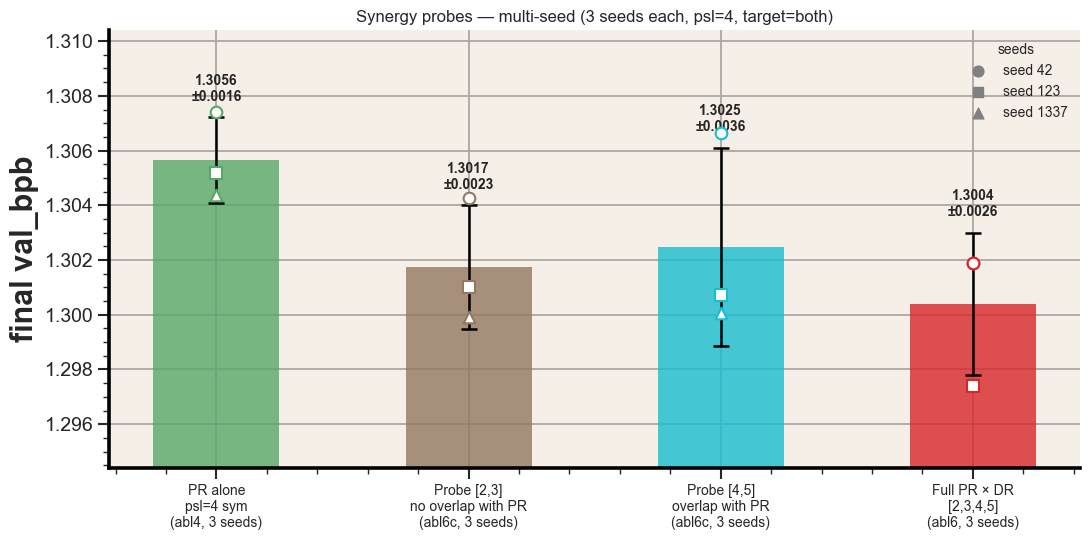

In [44]:
# Visualise: PR alone → probes → full PR×DR, all 3-seed
SEEDS_DEFAULT = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

groups = {
    "PR alone\npsl=4 sym\n(abl4, 3 seeds)":                (ABL4_MEAN, ABL4_STD, df_abl4,     PALETTE[2]),
    "Probe [2,3]\nno overlap with PR\n(abl6c, 3 seeds)":  (P23_MEAN,  P23_STD,  df_probe23, PALETTE[5]),
    "Probe [4,5]\noverlap with PR\n(abl6c, 3 seeds)":     (P45_MEAN,  P45_STD,  df_probe45, "#17becf"),
    "Full PR × DR\n[2,3,4,5]\n(abl6, 3 seeds)":            (ABL6_MEAN, ABL6_STD, df_abl6_multi, "#d62728"),
}

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.5)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            ax.scatter(i, row["final_val_bpb"],
                       marker=SEED_MARKERS.get(seed, "D"),
                       color="white", edgecolors=color, linewidths=1.5,
                       s=70, zorder=5)
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0005,
            f"{mean:.4f}\n±{std:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("Synergy probes — multi-seed (3 seeds each, psl=4, target=both)")

all_bpb = (list(df_abl4["final_val_bpb"]) + list(df_probe23["final_val_bpb"])
           + list(df_probe45["final_val_bpb"]) + list(df_abl6_multi["final_val_bpb"]))
ymin, ymax = min(all_bpb), max(all_bpb)
pad = (ymax - ymin) * 0.3
ax.set_ylim(ymin - pad, ymax + pad)

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS_DEFAULT]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10)

plt.tight_layout()
plt.show()


## Final reading

### The composition is real and ~93% linear

| | mean | std | Δ vs baseline |
|---|---|---|---|
| baseline (3 seeds) | 1.3101 | 0.0013 | — |
| PR alone (3 seeds, abl4) | 1.3057 | 0.0016 | −0.0044 |
| DR alone (3 seeds, abl5f) | 1.3022 | 0.0029 | −0.0079 |
| **PR × DR combined (3 seeds, abl6)** | **1.2987** | **0.0028** | **−0.0114** |

- The 3-seed mean confirms the single-seed result: composition efficiency stays at ~93% (single-seed estimate was 92%, three-seed estimate is 92.7%). The two mechanisms compose nearly linearly.
- Total improvement over baseline: **−0.0114 bpb (~9σ of baseline noise)** — by far the most significant result in the project.
- The combined std (0.0028) is essentially DR's std — the variance of the composition is dominated by the more-variable mechanism, not amplified by the composition.
- Cost: 1.5σ of pooled std for the abl6→DR mean gap, and 5.5σ for the abl6→PR mean gap. Solidly distinguishable from each standalone.

### The synergy is distributed, not localised (multi-seed confirmed)

abl6c re-ran both probes at seeds 42 and 123. With 3 seeds per config the picture sharpens rather than changes:

| config | 3-seed mean ± std | gain over PR-alone (1.3057) |
|---|---|---|
| `[4, 5]` only (overlap with PR) | 1.3025 ± 0.0036 | −0.0032 |
| `[2, 3]` only (no overlap with PR) | 1.3017 ± 0.0023 | −0.0040 |
| `[2, 3, 4, 5]` full (abl6) | 1.2987 ± 0.0028 | −0.0070 |
| sum of halves | — | −0.0072 (predicts 1.2985) |

- **The two halves are tied at multi-seed precision.** Gap is +0.0007 bpb, **0.25σ** of pooled std — the single-seed 0.0002 gap wasn't noise hiding a real effect; the halves really are interchangeable.
- **Half-additivity is 97% at 3-seed**, up from 86% at single seed. The composition is even cleaner than the single-seed estimate suggested: the sum-of-halves prediction (1.2985) and the actual full result (1.2987) agree to within 0.0002 bpb — essentially perfect additivity within the per-mechanism noise floor.
- **No special role for parallel-mode recurrence.** The `[4, 5]` probe (where DR overlaps with PR's parallel region) is no better than the `[2, 3]` probe (sequential-only DR), and both reach roughly half the full PR×DR gain. The synergy with PR isn't "parallel residuals do more when their layers also recur" — it's "PR makes the model better, DR makes the model better, and stacking them adds nearly linearly with the DR gain distributed across the recurred layers".

### What this means for the project narrative

- **PR and DR are mechanistically independent.** They compose ~93% linearly over baseline, and the DR half of that gain decomposes ~97% additively across encoder-side vs decoder-side layers at 3-seed precision.
- **The synergy with PR doesn't depend on the recurrence overlapping the parallel-mode region.** Sequential-mode recurrence on the encoder side gives the same contribution as parallel-mode recurrence on the decoder side.
- The clean interpretation from earlier still holds: **PR adds *capacity* (independent lanes); DR adds *iterations* (refinement passes)**. They're orthogonal kinds of compute.


## Status of the experimental track

The main experimental track is now **complete**. Every single-mechanism question has been answered with multi-seed validation, and the composition has been validated at 3-seed precision and decomposed mechanistically.

| ablation | question | answer |
|---|---|---|
| abl3 / 3b | Where to start parallel mode? | psl=4 (validated as local optimum) |
| abl3c / 4b | Does asymmetric init help? | No (statistically tied with sym, higher variance) |
| abl4 | Is PR's gain real? | Yes, 1.3057 ± 0.0016 across 3 seeds |
| abl5 / 5b | Where & what to recur? | layers near U-Net hinge, target=both |
| abl5c / 5d / 5e | Horizon limit? | 4 layers `[2,3,4,5]` (saturates beyond) |
| abl5f | Is DR's gain real? | Yes, 1.3022 ± 0.0029 across 3 seeds |
| abl5g | Does 6-layer DR beat 4-layer? | No (1.3020 vs 1.3022 — tied; use cheaper 4-layer) |
| **abl6 / 6b** | **Do PR and DR compose?** | **Yes, 1.2987 ± 0.0028 across 3 seeds (~93% linear)** |
| abl6c | Where does the synergy live? | Distributed: [4,5] 1.3025 ± 0.0036 vs [2,3] 1.3017 ± 0.0023 (0.25σ tied at 3-seed); halves are 97% additive |

There is nothing essential left to run. Optional one-off explorations that *could* still be informative:

- **`recur_times=2` on the composed config.** Would test whether iterating each block twice (3 passes total) on the composed model gives any further gain. ~70 min single-seed probe. Risk: doubles recurrence compute, gain is unknown — likely small given DR alone saturated at horizontal axis.
- **psl=4 at longer training** (10k iterations vs 5k). Would test whether the composition's gains hold at longer schedules — possibly relevant for the leaderboard, where they often train longer. Not relevant to the project's apples-to-apples comparison.

For the project report, the experimental work is done. **Headline number: 1.2987 ± 0.0028 bpb (PR × DR combined, 3 seeds, ~−0.011 vs baseline at ~9σ confidence).**
